# Predicting Prescription Pain-Reliever Misuse Using 2024 NSDUH Data

**Exploratory analysis and machine-learning classification of past-year prescription pain-reliever misuse among U.S. adults**

## Project Overview

This self-directed portfolio project examines which demographic, socioeconomic, health, mental-health, and substance-use characteristics are associated with reported past-year prescription pain-reliever misuse in the 2024 National Survey on Drug Use and Health (NSDUH).

**Research question:** Which selected characteristics are associated with past-year prescription pain-reliever misuse, and how effectively can classification models distinguish respondents who report misuse from those who do not?

The project demonstrates codebook-guided variable selection, data cleaning, missing-data handling, exploratory visualization, statistical association testing, feature engineering, class-imbalance handling, validation-based threshold tuning, model comparison, and interpretation.

> **Scope note:** NSDUH is cross-sectional. The models classify contemporaneous past-year reported misuse; they do not establish causation or predict future misuse.


## Data Source and Variable Selection

The analysis uses the 2024 National Survey on Drug Use and Health (NSDUH) public-use file from SAMHSA. The raw public-use ZIP is not included in this repository; download it from SAMHSA and place it in your local Downloads folder before running the notebook.

Initial variables were selected from demographic, socioeconomic, health, mental-health, and substance-use domains. Variable definitions and coding decisions were checked against the official 2024 NSDUH codebook before cleaning or recoding.


In [1]:
from pathlib import Path
import zipfile
import pandas as pd

downloads = Path.home() / "Downloads"

for file in downloads.glob("NSDUH*.zip"):
    print(file)

KeyboardInterrupt: 

In [ ]:
zip_path = Path.home() / "Downloads" / "NSDUH-2024-DS0001-bndl-data-tsv_v1.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print(z.namelist())

In [ ]:
with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("NSDUH_2024_Tab.txt") as f:
        columns = pd.read_csv(f, sep="\t", nrows=0).columns.tolist()

print(f"Number of columns: {len(columns)}")
print(columns[:50])

In [ ]:
starter_vars = [
    "QUESTID2",      # respondent ID
    "ANALWT2_C",     # survey weight
    "CATAG6",        # age category
    "IRSEX",         # sex
    "NEWRACE2",      # race/ethnicity
    "EDUHIGHCAT",    # education
    "IRWRKSTAT18",   # employment status, adults 18+
    "INCOME",        # family income category
    "HEALTH2",       # overall health
    "IRINSUR4",      # health insurance
    "PNRNMYR"        # target: past-year pain-reliever misuse
]

for var in starter_vars:
    print(var, "FOUND" if var in columns else "NOT FOUND")


In [ ]:
mental_health_vars = [
    "AGADSCED",       # GAD-7 anxiety score, past 2 weeks
    "KSSLR6MONED",    # K6 psychological distress, past 30 days
    "KSSLR6MAX",      # worst K6 psychological distress, past year
    "IRAMDEYR"        # past-year major depressive episode
]

for var in mental_health_vars:
    print(var, "FOUND" if var in columns else "NOT FOUND")

In [ ]:
substance_vars = [
    "IRPMNICDEP",   # past-month nicotine dependence
    "PYUD5ALC",     # past-year alcohol use disorder
    "PYUD5MRJ"      # past-year marijuana use disorder
]

for var in substance_vars:
    print(var, "FOUND" if var in columns else "NOT FOUND")

In [ ]:
selected_vars = [
    # Record / survey information
    "QUESTID2",        # respondent ID
    "ANALWT2_C",       # survey weight

    # Demographics / socioeconomic
    "CATAG6",          # age category
    "IRSEX",           # sex
    "NEWRACE2",        # race/ethnicity
    "EDUHIGHCAT",      # education
    "IRWRKSTAT18",     # adult employment status
    "INCOME",          # family income category
# General health
    "HEALTH2",         # overall health
    "IRINSUR4",        # health insurance coverage

    # Mental health
    "AGADSCED",        # GAD-7 anxiety score
    "KSSLR6MONED",     # K6 psychological distress, past 30 days
    "KSSLR6MAX",       # worst K6 distress, past year - secondary analysis
    "IRAMDEYR",        # past-year major depressive episode
 # Other substance-use factors
    "IRPMNICDEP",      # past-month nicotine dependence
    "PYUD5ALC",        # past-year alcohol use disorder
    "PYUD5MRJ",        # past-year marijuana use disorder

    # Target
    "PNRNMYR"          # past-year prescription pain-reliever misuse
]

In [ ]:
with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("NSDUH_2024_Tab.txt") as f:
        df = pd.read_csv(
            f,
            sep="\t",
            usecols=selected_vars
        )
print(df.shape)
df.head()

## Data Preparation and Cleaning

The analytical sample is restricted to adults age 18 or older. Cleaning focuses on duplicate checks, valid code ranges, missingness, use of official imputation-revised NSDUH variables where appropriate, and preservation of survey weights for descriptive estimates.

Missing mental-health scores are retained rather than dropping otherwise usable respondents; missingness indicators are created for modeling when appropriate.


In [ ]:
original_rows = len(df)
df = df[df["CATAG6"] != 1].copy()

print("Original rows:", original_rows)
print("Adult rows:", len(df))


In [ ]:
print("Duplicate respondent IDs:", df["QUESTID2"].duplicated().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))


In [ ]:
adult_df.info()

In [ ]:
print(adult_df["PNRNMYR"].value_counts()) 
print("\nPercent:") 
print(adult_df["PNRNMYR"].value_counts(normalize=True) * 100)

In [ ]:
# Verify actual CATAG6 values in subset
# No missing values
df["CATAG6"].value_counts().sort_index()

In [ ]:
# Verify actual IRSEX values in subset
# No missing values
df["IRSEX"].value_counts().sort_index()

In [ ]:
# Verify actual NEWRACE2 values in subset
# No missing values
# Nominal categorical data that will need be one-not encoded so the predictive model does not treat 7 as greater than 1
df["NEWRACE2"].value_counts().sort_index()

In [ ]:
# Verify actual EDUHIGHCAT values in subset
# Category 5 represents respondents ages 12-17 and should be absent
# No missing values
# One-not encodinh will be considered for modeling to avoid assuming equal numeric distance between education levels
df["EDUHIGHCAT"].value_counts().sort_index()

In [ ]:
# IRWRKSTAT18 is nominal categorical employment status for adults
# Code 99 represents repsondents ages 12-17 which have been excluded from the adult only subset
# One-hot encode before modeling 
# No missing vlaues
df["IRWRKSTAT18"].value_counts().sort_index()

In [ ]:
# iNCOME is ordinal categorical data representing total family income 
# No missing values 
# One-hot enconding will be considered before modeling to avoid assuming equal numeric spacing between income levels
df["INCOME"].value_counts().sort_index()

In [ ]:
# Verify HEALTH2 values, including missing values 
df["HEALTH2"].value_counts(dropna=False).sort_index()

In [ ]:
# Check target distribution among records missing HEALTH2 
df.loc[df["HEALTH2"].isna(), "PNRNMYR"].value_counts()

In [ ]:
# Create a working copy for cleaning
clean_df = df.copy()

# Remove records with unknown overall health status
clean_df = clean_df.dropna(subset=["HEALTH2"]).copy()

print("Original rows:", len(df))
print("Rows after removing missing HEALTH2:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

In [ ]:
# Verify AGADSCED valid range and missingness
print(clean_df["AGADSCED"].describe())

print("\nMissing AGADSCED values:")
print(clean_df["AGADSCED"].isna().sum())

In [ ]:
# Check pain-reliever misuse among records missing AGADSCED
clean_df.loc[
    clean_df["AGADSCED"].isna(),
    "PNRNMYR"
].value_counts()

In [ ]:
clean_df["AGADSCED_Missing"] = clean_df["AGADSCED"].isna().astype(int)

clean_df["AGADSCED_Missing"].value_counts().sort_index()

In [ ]:
# AGADSCED is a continuous GAD-7 total score ranging from 0 to 21.
# In the full NSDUH file, missing values include respondents ages 12-17
# and adults with unavailable scores. Because the analysis is adult-only,
# remaining NaN values represent missing adult GAD-7 scores.
# AGADSCED_Missing
# 0 = GAD-7 score available
# 1 = GAD-7 score missing
df["AGADSCED"].value_counts().sort_index()

In [ ]:
# Verify KSSLR6MONED range and missingness
print(clean_df["KSSLR6MONED"].describe())

print("\nMissing KSSLR6MONED values:")
print(clean_df["KSSLR6MONED"].isna().sum())

In [ ]:
# Check pain-reliever misuse among records missing KSSLR6MONED
clean_df.loc[
    clean_df["KSSLR6MONED"].isna(),
    "PNRNMYR"
].value_counts()

In [ ]:
# Create missingness indicator for KSSLR6MONED
clean_df["KSSLR6MONED_Missing"] = clean_df["KSSLR6MONED"].isna().astype(int)

clean_df["KSSLR6MONED_Missing"].value_counts().sort_index()

In [ ]:
# PYUD5ALC contains missing and special-use categories.
# The NSDUH codebook provides IRPYUD5ALC, an imputation-revised
# binary version of past-year alcohol use disorder.
# Use the official NSDUH-derived variable rather than manually
# recoding or imputing PYUD5ALC.

# Load respondent ID and the imputation-revised alcohol use disorder variable
with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("NSDUH_2024_Tab.txt") as f:
        alcohol_revised = pd.read_csv(
            f,
            sep="\t",
            usecols=["QUESTID2", "IRPYUD5ALC"]
        )
# Merge the revised variable into the current cleaned dataset
clean_df = clean_df.merge(
    alcohol_revised,
    on="QUESTID2",
    how="left",
    validate="one_to_one"
)
# Remove the original PYUD5ALC variable
clean_df = clean_df.drop(columns=["PYUD5ALC"])

# Verify the revised variable
clean_df["IRPYUD5ALC"].value_counts(dropna=False).sort_index()

In [ ]:
# Validate 
print("Rows in clean_df:", len(clean_df))
print("Duplicate QUESTID2 values:", clean_df["QUESTID2"].duplicated().sum())

print("PYUD5ALC" in clean_df.columns)
print("IRPYUD5ALC" in clean_df.columns)

print("Missing IRPYUD5ALC values:",
      clean_df["IRPYUD5ALC"].isna().sum())

In [ ]:
# Use the official imputation-revised marijuana use-disorder variable.
with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("NSDUH_2024_Tab.txt") as f:
        marijuana_revised = pd.read_csv(
            f,
            sep="\t",
            usecols=["QUESTID2", "IRPYUD5MRJ"]
        )

clean_df = clean_df.merge(
    marijuana_revised,
    on="QUESTID2",
    how="left",
    validate="one_to_one"
)

clean_df = clean_df.drop(columns=["PYUD5MRJ"])

print("Rows in clean_df:", len(clean_df))
print("Duplicate QUESTID2 values:", clean_df["QUESTID2"].duplicated().sum())
print("Missing IRPYUD5MRJ values:", clean_df["IRPYUD5MRJ"].isna().sum())
print(clean_df["IRPYUD5MRJ"].value_counts().sort_index())


In [ ]:
print("Rows in clean_df:", len(clean_df))
print("Duplicate QUESTID2 values:", clean_df["QUESTID2"].duplicated().sum())
print("Missing IRPYUD5MRJ values:", clean_df["IRPYUD5MRJ"].isna().sum())

print("\nIRPYUD5MRJ distribution:")
print(clean_df["IRPYUD5MRJ"].value_counts().sort_index())


In [ ]:
clean_df.to_csv(
    "NSDUH_2024_Opioid_Misuse_Cleaning_Checkpoint.csv",
    index=False
)

print("Cleaning checkpoint saved:", clean_df.shape)

In [ ]:
# Continue with the cleaned in-memory analytical dataset.
print(clean_df.shape)
print(clean_df.columns.tolist())


In [ ]:
clean_df["IRINSUR4"].value_counts().sort_index()

In [ ]:
clean_df["IRPMNICDEP"].value_counts().sort_index()

In [ ]:
# KSSLR6MAX is the worst K6 psychological-distress score in the past year.
# Valid range: 0-24.
# Exclude from the primary predictive model because its past-year
# time window overlaps with the past-year misuse outcome.
# No adult missing values are expected after excluding respondents ages 12-17.
# Retain for descriptive/secondary analysis, but exclude from the primary model
# because its past-year time window overlaps with the past-year misuse outcome.

print(clean_df["KSSLR6MAX"].describe())
print("Missing values:", clean_df["KSSLR6MAX"].isna().sum())

In [ ]:
clean_df["IRAMDEYR"].value_counts(dropna=False).sort_index()

In [ ]:
# ANALWT2_C:
# Survey sample weight used for weighted descriptive/population estimates.
# Retain in the dataset, but do not use as a predictor feature in the model.
clean_df["ANALWT2_C"].describe()

In [ ]:
# QUESTID2:
# Respondent identifier used for record tracking/merging only.
# Do not use as a predictor feature.
print(clean_df.shape)
print("\nDuplicate respondent IDs:", clean_df["QUESTID2"].duplicated().sum())
print("\nMissing values:")
print(clean_df.isna().sum().sort_values(ascending=False))

In [ ]:
# Final cleaning audit:
# 47,274 adult respondents remain in the analytical dataset.
# No duplicate respondent IDs are present.
# Missing values remain only in AGADSCED and KSSLR6MONED.
# Missingness indicators were created for both variables.
# These scores will be imputed later within the modeling pipeline to prevent data leakage.

clean_df.to_csv(
    "NSDUH_2024_Opioid_Misuse_Clean.csv",
    index=False
)

print("Saved:", clean_df.shape)


In [ ]:
clean_df.to_csv(
    "NSDUH_2024_Opioid_Misuse_Cleaned.csv",
    index=False
)

## Exploratory Data Analysis

Exploratory analysis examines the class imbalance in past-year prescription pain-reliever misuse and compares misuse rates across demographic, socioeconomic, health, mental-health, and substance-use characteristics.

Unless explicitly labeled as survey-weighted, percentages in this section describe the unweighted analytical sample.


In [2]:
import pandas as pd

clean_df = pd.read_csv("NSDUH_2024_Opioid_Misuse_Cleaned.csv")

print(clean_df.shape)
clean_df.head()

(47274, 20)


,QUESTID2,ANALWT2_C,IRSEX,CATAG6,NEWRACE2,EDUHIGHCAT,HEALTH2,IRWRKSTAT18,IRINSUR4,INCOME,IRPMNICDEP,PNRNMYR,AGADSCED,KSSLR6MONED,KSSLR6MAX,IRAMDEYR,AGADSCED_Missing,KSSLR6MONED_Missing,IRPYUD5ALC,IRPYUD5MRJ
0,10000616,1922.385971,2,3,1,4,1.0,1,1,4,0,0,0.0,3.0,3.0,0.0,0,0,0,0
1,10002171,335.358722,2,2,1,2,3.0,1,1,2,0,0,4.0,6.0,12.0,1.0,0,0,0,0
2,10004278,7372.604360,2,2,1,4,2.0,1,1,4,0,0,0.0,11.0,11.0,0.0,0,0,1,0
3,10004548,1047.354884,2,4,1,2,4.0,4,1,1,0,0,14.0,11.0,14.0,0.0,0,0,0,1
4,10004667,415.147501,2,2,7,1,1.0,1,2,2,0,0,0.0,0.0,0.0,0.0,0,0,0,0


In [3]:
target_counts = clean_df["PNRNMYR"].value_counts().sort_index()

target_percent = (
    clean_df["PNRNMYR"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Counts:")
print(target_counts)

print("\nPercentages:")
print(target_percent.round(2))

Counts:
PNRNMYR
0    45829
1     1445
Name: count, dtype: int64

Percentages:
PNRNMYR
0    96.94
1     3.06
Name: proportion, dtype: float64


The target variable is highly imbalanced.
Past-year prescription pain-reliever misuse was reported by 3.06%
of respondents in the unweighted adult analytical sample.
Because the positive class is rare, accuracy alone will not be
sufficient for evaluating predictive models.


In [5]:
weighted_target = (
    clean_df.groupby("PNRNMYR")["ANALWT2_C"]
    .sum()
)

weighted_percent = (
    weighted_target / weighted_target.sum() * 100
)

print("Survey-weighted percentages:")
print(weighted_percent.round(2))

# The unweighted analytical sample had a past-year prescription
# pain-reliever misuse rate of 3.06%.

# After applying the NSDUH survey weight (ANALWT2_C), the estimated
# prevalence was 2.80%.

# Survey weights are used for population-oriented descriptive estimates.
# The predictive modeling phase will be handled separately.

Survey-weighted percentages:
PNRNMYR
0    97.2
1     2.8
Name: ANALWT2_C, dtype: float64


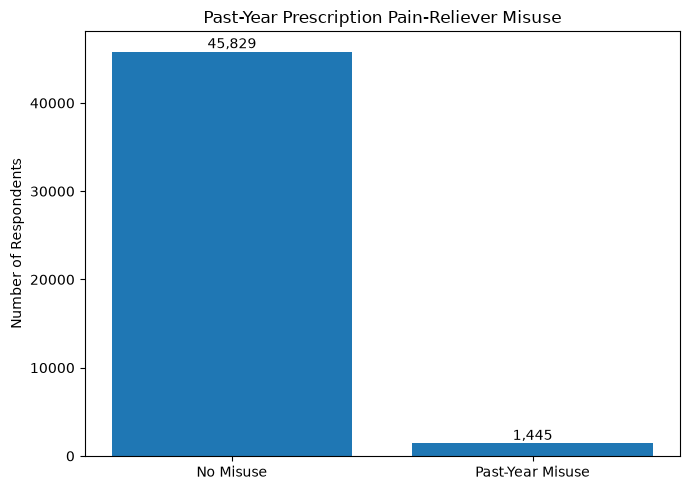

In [6]:
import matplotlib.pyplot as plt

labels = ["No Misuse", "Past-Year Misuse"]
counts = [
    (clean_df["PNRNMYR"] == 0).sum(),
    (clean_df["PNRNMYR"] == 1).sum()
]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, counts)

plt.title("Past-Year Prescription Pain-Reliever Misuse")
plt.ylabel("Number of Respondents")
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The class distribution is highly imbalanced.
Of 47,274 adults in the analytical sample, 45,829 reported no
past-year prescription pain-reliever misuse and 1,445 reported misuse.
This imbalance will be accounted for during model development
and evaluation.


In [8]:
age_misuse = (
    clean_df.groupby("CATAG6")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

age_misuse["Misuse_Percent"] = age_misuse["mean"] * 100

age_misuse

,count,sum,mean,Misuse_Percent
CATAG6,,,,
2,14125,372,0.026336,2.633628
3,9618,284,0.029528,2.952797
4,12840,514,0.040031,4.003115
5,5195,164,0.031569,3.156882
6,5496,111,0.020197,2.019651


Past-year prescription pain-reliever misuse varied across age groups.
The highest unweighted misuse rate was observed among adults ages 35-49
(4.00%), while adults ages 65+ had the lowest rate (2.02%).
These are descriptive associations within the analytical sample and
should not be interpreted as evidence that age causes misuse.


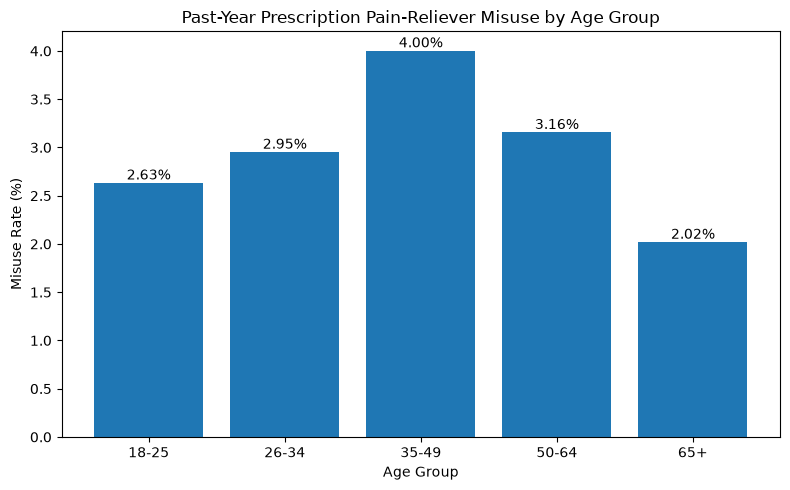

In [10]:
age_labels = ["18-25", "26-34", "35-49", "50-64", "65+"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    age_labels,
    age_misuse["Misuse_Percent"]
)

plt.title("Past-Year Prescription Pain-Reliever Misuse by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Misuse Rate (%)")
for bar, value in zip(bars, age_misuse["Misuse_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The highest observed past-year prescription pain-reliever misuse rate
occurred among adults ages 35-49 (4.00%), while adults ages 65+
had the lowest observed rate (2.02%).
These results describe the analytical sample and do not imply causation.


In [12]:
sex_misuse = (
    clean_df.groupby("IRSEX")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

sex_misuse["Misuse_Percent"] = sex_misuse["mean"] * 100

sex_misuse

,count,sum,mean,Misuse_Percent
IRSEX,,,,
1,21226,648,0.030529,3.052860
2,26048,797,0.030597,3.059736


Past-year prescription pain-reliever misuse rates were nearly identical
by sex in the unweighted analytical sample.
Male respondents had a misuse rate of 3.053%, compared with 3.060%
among female respondents.
Formal association testing will be performed later before drawing
conclusions about whether sex is statistically associated with misuse.


In [14]:
race_misuse = (
    clean_df.groupby("NEWRACE2")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

race_misuse["Misuse_Percent"] = race_misuse["mean"] * 100

race_misuse

,count,sum,mean,Misuse_Percent
NEWRACE2,,,,
1,27454,805,0.029322,2.932177
2,5644,207,0.036676,3.667612
3,696,33,0.047414,4.741379
4,237,8,0.033755,3.375527
5,2272,32,0.014085,1.408451
6,1921,72,0.037480,3.748048
7,9050,288,0.031823,3.182320


Past-year prescription pain-reliever misuse rates varied across
race/ethnicity groups in the unweighted analytical sample.
The highest observed rate was among non-Hispanic American Indian/
Alaska Native respondents (4.74%), while non-Hispanic Asian
respondents had the lowest observed rate (1.41%).
Some groups have substantially smaller sample sizes, so differences
should be interpreted cautiously and not as evidence of causation.


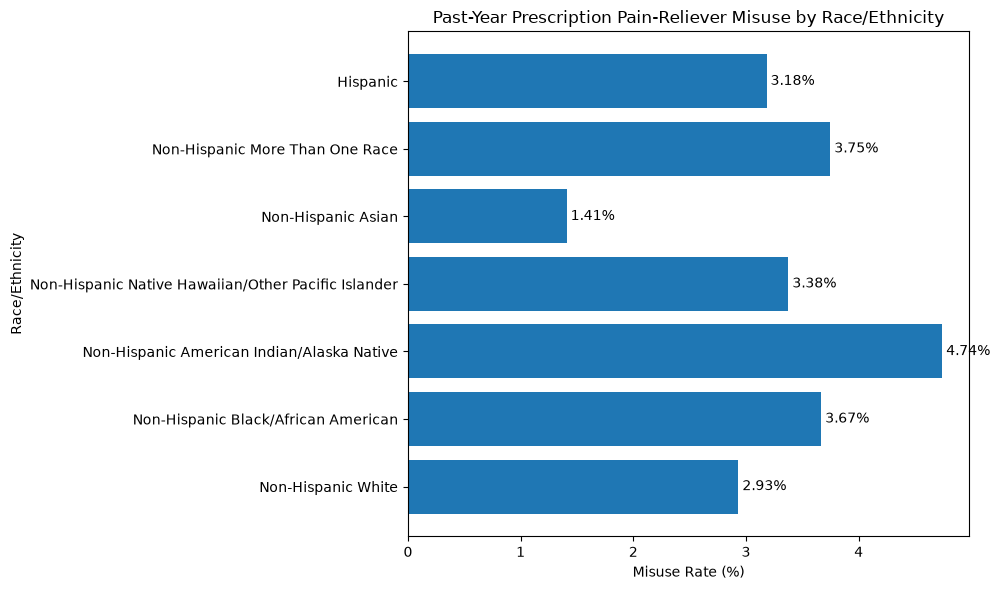

In [16]:
race_labels = {
    1: "Non-Hispanic White",
    2: "Non-Hispanic Black/African American",
    3: "Non-Hispanic American Indian/Alaska Native",
    4: "Non-Hispanic Native Hawaiian/Other Pacific Islander",
    5: "Non-Hispanic Asian",
    6: "Non-Hispanic More Than One Race",
    7: "Hispanic"
}
race_chart = race_misuse.copy()
race_chart["Race_Ethnicity"] = race_chart.index.map(race_labels)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    race_chart["Race_Ethnicity"],
    race_chart["Misuse_Percent"]
)
plt.title("Past-Year Prescription Pain-Reliever Misuse by Race/Ethnicity")
plt.xlabel("Misuse Rate (%)")
plt.ylabel("Race/Ethnicity")

for bar, value in zip(bars, race_chart["Misuse_Percent"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

Misuse rates varied across race/ethnicity groups in the unweighted sample.
The highest observed rate was among non-Hispanic American Indian/Alaska Native
respondents (4.74%), while non-Hispanic Asian respondents had the lowest
observed rate (1.41%).
Smaller subgroup sample sizes should be interpreted cautiously.


In [18]:
education_misuse = (
    clean_df.groupby("EDUHIGHCAT")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

education_misuse["Misuse_Percent"] = education_misuse["mean"] * 100

education_misuse

,count,sum,mean,Misuse_Percent
EDUHIGHCAT,,,,
1,4959,231,0.046582,4.658197
2,12883,482,0.037414,3.741365
3,13472,435,0.032289,3.228919
4,15960,297,0.018609,1.860902


Past-year prescription pain-reliever misuse rates decreased across
progressively higher education categories in the unweighted sample.
Respondents with less than a high school education had the highest
observed misuse rate (4.66%), while college graduates had the lowest
observed rate (1.86%).
These results show an association and do not imply causation.


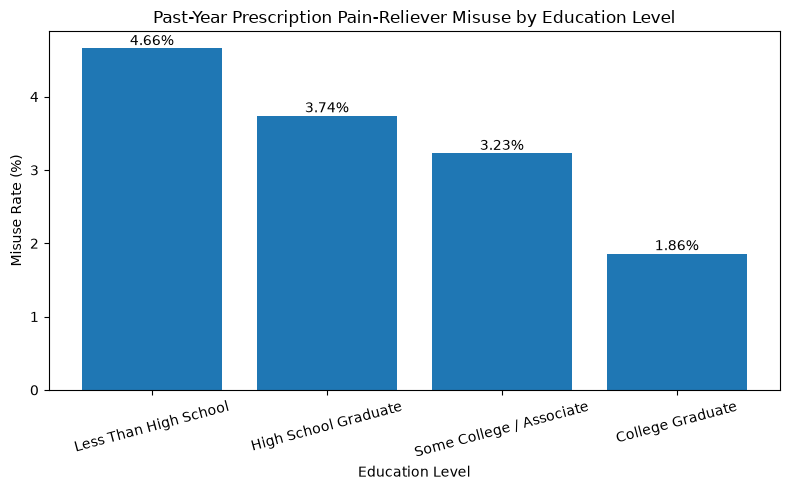

In [20]:
education_labels = [
    "Less Than High School",
    "High School Graduate",
    "Some College / Associate",
    "College Graduate"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    education_labels,
    education_misuse["Misuse_Percent"]
)

plt.title("Past-Year Prescription Pain-Reliever Misuse by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Misuse Rate (%)")

for bar, value in zip(bars, education_misuse["Misuse_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The pattern reads immediately: 
The observed misuse rate falls from 4.66% among respondents with less than a high school education to 1.86% among college graduates.


In [22]:
employment_misuse = (
    clean_df.groupby("IRWRKSTAT18")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

employment_misuse["Misuse_Percent"] = employment_misuse["mean"] * 100

employment_misuse

,count,sum,mean,Misuse_Percent
IRWRKSTAT18,,,,
1,22894,615,0.026863,2.686293
2,7155,190,0.026555,2.655486
3,3107,159,0.051175,5.117477
4,14118,481,0.034070,3.406998


IRWRKSTAT18 employment status codes:
1 = Full time
2 = Part time
3 = Unemployed
4 = Other / not in the labor force

Past-year prescription pain-reliever misuse varied by employment status.
Full-time and part-time respondents had similar observed misuse rates
(2.69% and 2.66%), while unemployed respondents had the highest rate
at 5.12%. Respondents classified as other/not in the labor force had
an observed rate of 3.41%.
These results are descriptive associations and do not imply causation.


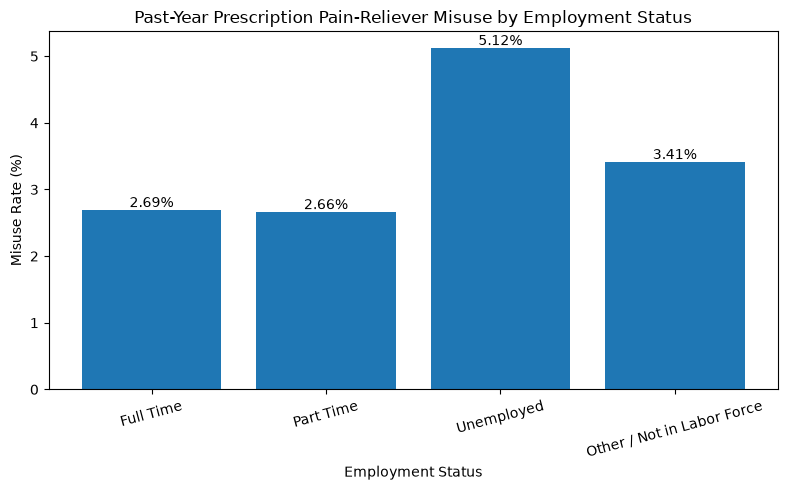

In [23]:
employment_labels = [
    "Full Time",
    "Part Time",
    "Unemployed",
    "Other / Not in Labor Force"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    employment_labels,
    employment_misuse["Misuse_Percent"]
)

plt.title("Past-Year Prescription Pain-Reliever Misuse by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Misuse Rate (%)")

for bar, value in zip(bars, employment_misuse["Misuse_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [24]:
income_misuse = (
    clean_df.groupby("INCOME")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

income_misuse["Misuse_Percent"] = income_misuse["mean"] * 100

income_misuse

,count,sum,mean,Misuse_Percent
INCOME,,,,
1,7731,401,0.051869,5.186910
2,12016,435,0.036202,3.620173
3,7216,197,0.027300,2.730044
4,20311,412,0.020285,2.028457


INCOME total family income codes:
1 = Less than $20,000
2 = $20,000-$49,999
3 = $50,000-$74,999
4 = $75,000 or more

Past-year prescription pain-reliever misuse decreased across
progressively higher family-income categories in the unweighted sample.
Respondents with family income below $20,000 had the highest observed
misuse rate (5.19%), while respondents with family income of $75,000
or more had the lowest observed rate (2.03%).
These results show an association and do not imply causation.


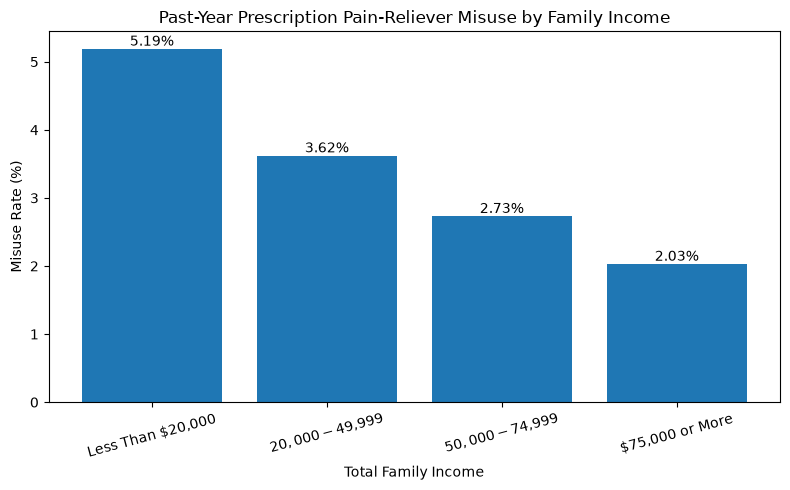

In [25]:
income_labels = [
    "Less Than $20,000",
    "$20,000-$49,999",
    "$50,000-$74,999",
    "$75,000 or More"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    income_labels,
    income_misuse["Misuse_Percent"]
)

plt.title("Past-Year Prescription Pain-Reliever Misuse by Family Income")
plt.xlabel("Total Family Income")
plt.ylabel("Misuse Rate (%)")

for bar, value in zip(bars, income_misuse["Misuse_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

A clear inverse pattern was observed between total family income
and past-year prescription pain-reliever misuse in the unweighted sample.
Misuse rates were highest in the lowest income category (5.19%)
and lowest in the highest income category (2.03%).
This is a descriptive association and does not establish causation.


In [26]:
# HEALTH2 overall health codes:
# 1 = Excellent
# 2 = Very Good
# 3 = Good
# 4 = Fair/Poor

health_misuse = (
    clean_df.groupby("HEALTH2")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

health_misuse["Misuse_Percent"] = health_misuse["mean"] * 100

health_misuse

,count,sum,mean,Misuse_Percent
HEALTH2,,,,
1.0,9171,170,0.018537,1.853669
2.0,17179,375,0.021829,2.182898
3.0,14936,541,0.036221,3.622121
4.0,5988,359,0.059953,5.995324


HEALTH2 overall health codes:
1 = Excellent
2 = Very Good
3 = Good
4 = Fair/Poor

Past-year prescription pain-reliever misuse increased as self-reported
overall health declined in the unweighted analytical sample.
Respondents reporting excellent health had the lowest observed misuse
rate (1.85%), while respondents reporting fair/poor health had the
highest observed rate (6.00%).
These results show a descriptive association and do not imply causation.


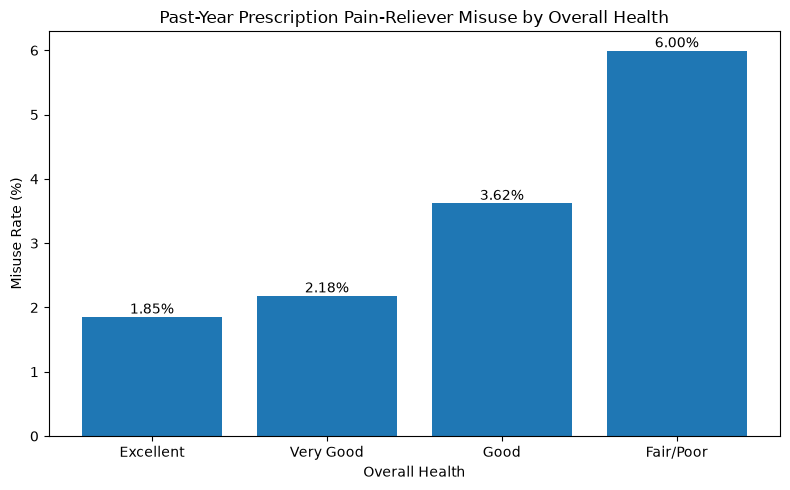

In [27]:
health_labels = [
    "Excellent",
    "Very Good",
    "Good",
    "Fair/Poor"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    health_labels,
    health_misuse["Misuse_Percent"]
)

plt.title("Past-Year Prescription Pain-Reliever Misuse by Overall Health")
plt.xlabel("Overall Health")
plt.ylabel("Misuse Rate (%)")

for bar, value in zip(bars, health_misuse["Misuse_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [28]:
# IRINSUR4 health insurance codes:
# 1 = Covered by health insurance
# 2 = Not covered by health insurance
insurance_misuse = (
    clean_df.groupby("IRINSUR4")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

insurance_misuse["Misuse_Percent"] = insurance_misuse["mean"] * 100

insurance_misuse

,count,sum,mean,Misuse_Percent
IRINSUR4,,,,
1,42013,1239,0.029491,2.949087
2,5261,206,0.039156,3.915605


IRINSUR4 health insurance codes:
1 = Covered by health insurance
2 = Not covered by health insurance

Past-year prescription pain-reliever misuse was somewhat higher among
respondents without health insurance (3.92%) than among respondents
with health insurance (2.95%) in the unweighted analytical sample.
These results are descriptive associations and do not imply causation.


In [29]:
# AGADSCED:
# GAD-7 anxiety symptom score over the past 2 weeks.
# Valid range = 0-21, with higher scores indicating greater anxiety symptoms.
# Missing values were intentionally retained and will be handled later within the predictive modeling pipeline.

anxiety_by_misuse = (
    clean_df.groupby("PNRNMYR")["AGADSCED"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

anxiety_by_misuse

,count,mean,median,std,min,max
PNRNMYR,,,,,,
0,44276,3.020417,1.0,4.513393,0.0,21.0
1,1364,5.673754,4.0,6.176888,0.0,21.0


PNRNMYR outcome codes:
0 = No past-year prescription pain-reliever misuse
1 = Past-year prescription pain-reliever misuse

Among respondents with valid GAD-7 scores, those reporting past-year
prescription pain-reliever misuse had higher anxiety symptom scores.
The misuse group had a mean GAD-7 score of 5.67 and median of 4,
compared with a mean of 3.02 and median of 1 in the no-misuse group.
Both groups covered the full 0-21 score range, indicating substantial
overlap between groups.
Missing AGADSCED values remain intentionally un-imputed at this stage.


<Figure size 700x500 with 0 Axes>

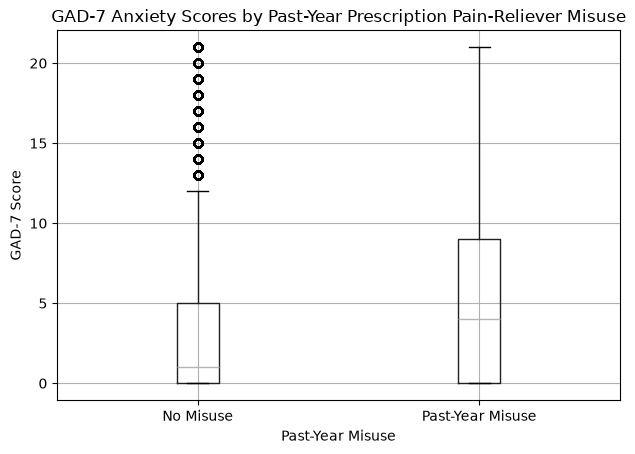

In [30]:
plt.figure(figsize=(7, 5))

clean_df.boxplot(
    column="AGADSCED",
    by="PNRNMYR"
)

plt.title("GAD-7 Anxiety Scores by Past-Year Prescription Pain-Reliever Misuse")
plt.suptitle("")
plt.xlabel("Past-Year Misuse")
plt.ylabel("GAD-7 Score")

plt.xticks([1, 2], ["No Misuse", "Past-Year Misuse"])

plt.tight_layout()
plt.show()

The GAD-7 distribution was shifted toward higher scores among respondents
reporting past-year prescription pain-reliever misuse.
The misuse group had a higher median score (4) than the no-misuse group (1),
although substantial overlap remained between the two distributions.
Boxplot outliers represent valid high anxiety scores and are not removed.


In [31]:
# KSSLR6MONED:
# K6 psychological distress score during the past 30 days.
# Valid range = 0-24, with higher scores indicating greater distress.
# Missing values remain intentionally un-imputed at this stage.

distress_by_misuse = (
    clean_df.groupby("PNRNMYR")["KSSLR6MONED"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

distress_by_misuse

,count,mean,median,std,min,max
PNRNMYR,,,,,,
0,44428,5.063969,4.0,5.250088,0.0,24.0
1,1373,8.262928,7.0,6.673677,0.0,24.0


Among respondents with valid K6 scores, those reporting past-year
prescription pain-reliever misuse had higher psychological distress.
The misuse group had a mean K6 score of 8.26 and median of 7,
compared with a mean of 5.06 and median of 4 in the no-misuse group.
Both groups covered the full 0-24 range, indicating substantial overlap.
Missing KSSLR6MONED values remain intentionally un-imputed at this stage.


<Figure size 700x500 with 0 Axes>

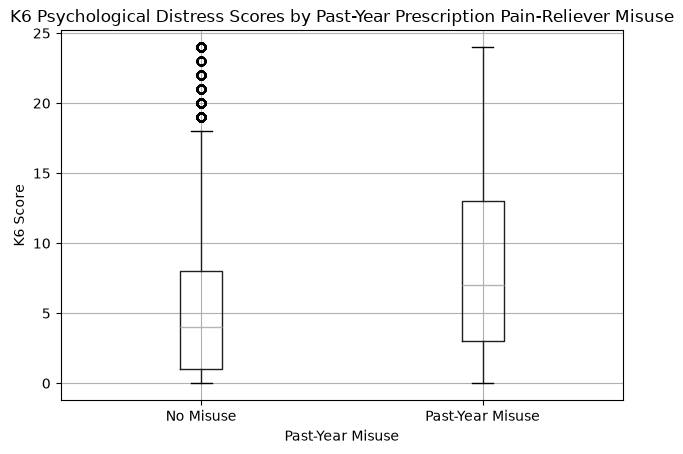

In [32]:
plt.figure(figsize=(7, 5))

clean_df.boxplot(
    column="KSSLR6MONED",
    by="PNRNMYR"
)

plt.title("K6 Psychological Distress Scores by Past-Year Prescription Pain-Reliever Misuse")
plt.suptitle("")
plt.xlabel("Past-Year Misuse")
plt.ylabel("K6 Score")

plt.xticks([1, 2], ["No Misuse", "Past-Year Misuse"])

plt.tight_layout()
plt.show()

The K6 psychological-distress distribution was shifted toward higher
scores among respondents reporting past-year prescription pain-reliever misuse.
The misuse group had a median K6 score of 7, compared with 4 in the
no-misuse group, although substantial overlap remained between groups.
Boxplot outliers represent valid high-distress scores and are retained.


In [33]:
# IRAMDEYR past-year major depressive episode codes:
# 0 = No
# 1 = Yes

depression_misuse = (
    clean_df.groupby("IRAMDEYR")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

depression_misuse["Misuse_Percent"] = depression_misuse["mean"] * 100

depression_misuse

,count,sum,mean,Misuse_Percent
IRAMDEYR,,,,
0.0,42075,1157,0.027499,2.749851
1.0,5199,288,0.055395,5.539527


IRAMDEYR past-year major depressive episode codes:
0 = No
1 = Yes

Past-year prescription pain-reliever misuse was higher among respondents who experienced a past-year major depressive episode.
Respondents without a past-year major depressive episode had an observed misuse rate of 2.75%, compared with 5.54% among respondents who experienced one.
These results show a descriptive association and do not imply causation.


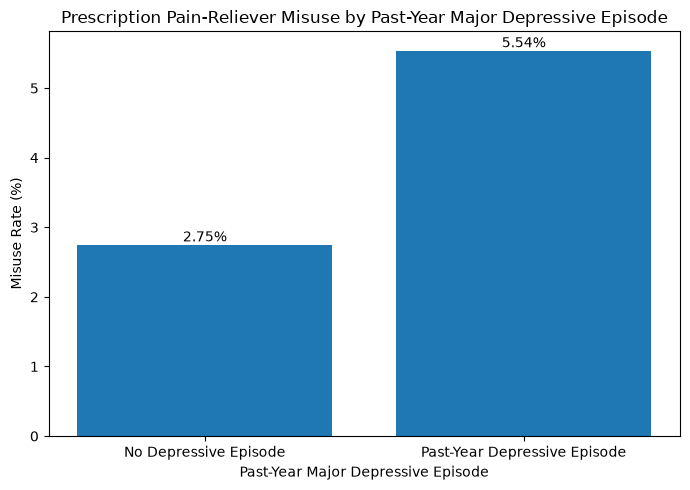

In [34]:
depression_labels = [
    "No Depressive Episode",
    "Past-Year Depressive Episode"
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    depression_labels,
    depression_misuse["Misuse_Percent"]
)

plt.title("Prescription Pain-Reliever Misuse by Past-Year Major Depressive Episode")
plt.xlabel("Past-Year Major Depressive Episode")
plt.ylabel("Misuse Rate (%)")

for bar, value in zip(bars, depression_misuse["Misuse_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [35]:
# IRPMNICDEP past-month nicotine dependence codes:
# 0 = No
# 1 = Yes

nicotine_misuse = (
    clean_df.groupby("IRPMNICDEP")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

nicotine_misuse["Misuse_Percent"] = nicotine_misuse["mean"] * 100

nicotine_misuse

,count,sum,mean,Misuse_Percent
IRPMNICDEP,,,,
0,43521,1039,0.023874,2.387353
1,3753,406,0.108180,10.818012


IRPMNICDEP past-month nicotine dependence codes:
0 = No
1 = Yes

Past-year prescription pain-reliever misuse was substantially higher
among respondents with past-month nicotine dependence.
Respondents without nicotine dependence had an observed misuse rate
of 2.39%, compared with 10.82% among respondents with nicotine dependence.
These results show a descriptive association and do not imply causation.


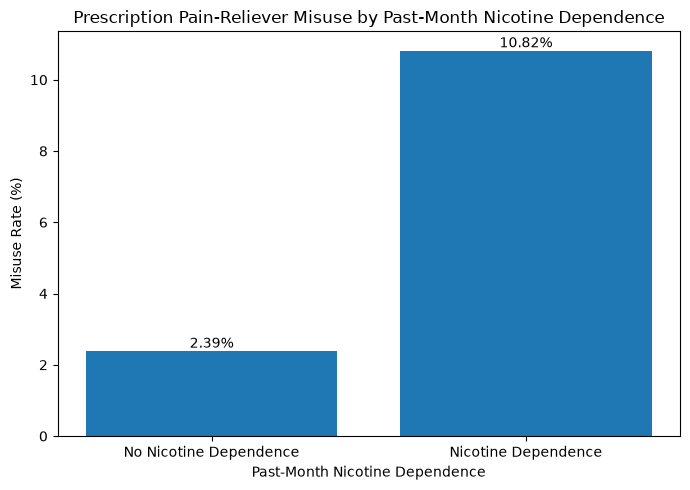

In [36]:
nicotine_labels = [
    "No Nicotine Dependence",
    "Nicotine Dependence"
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    nicotine_labels,
    nicotine_misuse["Misuse_Percent"]
)

plt.title(
    "Prescription Pain-Reliever Misuse by Past-Month Nicotine Dependence"
)
plt.xlabel("Past-Month Nicotine Dependence")
plt.ylabel("Misuse Rate (%)")

for bar, value in zip(bars, nicotine_misuse["Misuse_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [37]:
# IRPYUD5ALC past-year alcohol use disorder codes:
# 0 = No
# 1 = Yes

alcohol_misuse = (
    clean_df.groupby("IRPYUD5ALC")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

alcohol_misuse["Misuse_Percent"] = alcohol_misuse["mean"] * 100

alcohol_misuse

,count,sum,mean,Misuse_Percent
IRPYUD5ALC,,,,
0,41559,1013,0.024375,2.437498
1,5715,432,0.075591,7.559055


IRPYUD5ALC past-year alcohol use disorder codes:
0 = No
1 = Yes

Past-year prescription pain-reliever misuse was higher among respondents
with past-year alcohol use disorder.
Respondents without alcohol use disorder had an observed misuse rate
of 2.44%, compared with 7.56% among respondents with alcohol use disorder.
These results show a descriptive association and do not imply causation.


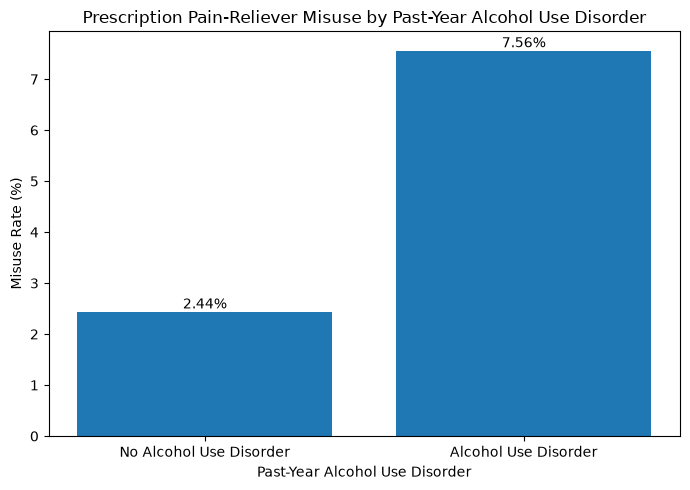

In [38]:
alcohol_labels = [
    "No Alcohol Use Disorder",
    "Alcohol Use Disorder"
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    alcohol_labels,
    alcohol_misuse["Misuse_Percent"]
)

plt.title(
    "Prescription Pain-Reliever Misuse by Past-Year Alcohol Use Disorder"
)
plt.xlabel("Past-Year Alcohol Use Disorder")
plt.ylabel("Misuse Rate (%)")

for bar, value in zip(bars, alcohol_misuse["Misuse_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [39]:
# IRPYUD5MRJ past-year marijuana use disorder codes:
# 0 = No
# 1 = Yes

marijuana_misuse = (
    clean_df.groupby("IRPYUD5MRJ")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

marijuana_misuse["Misuse_Percent"] = marijuana_misuse["mean"] * 100

marijuana_misuse

,count,sum,mean,Misuse_Percent
IRPYUD5MRJ,,,,
0,42504,1039,0.024445,2.444476
1,4770,406,0.085115,8.511530


IRPYUD5MRJ past-year marijuana use disorder codes:
0 = No
1 = Yes

Past-year prescription pain-reliever misuse was higher among respondents
with past-year marijuana use disorder.
Respondents without marijuana use disorder had an observed misuse rate
of 2.44%, compared with 8.51% among respondents with marijuana use disorder.
These results show a descriptive association and do not imply causation.


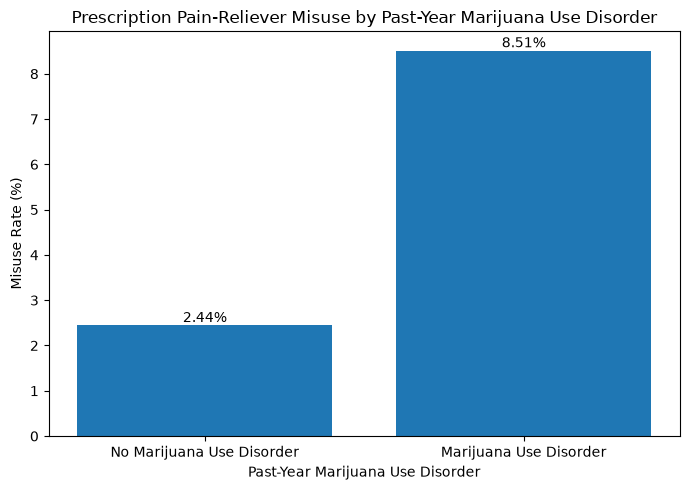

In [40]:
marijuana_labels = [
    "No Marijuana Use Disorder",
    "Marijuana Use Disorder"
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    marijuana_labels,
    marijuana_misuse["Misuse_Percent"]
)

plt.title(
    "Prescription Pain-Reliever Misuse by Past-Year Marijuana Use Disorder"
)
plt.xlabel("Past-Year Marijuana Use Disorder")
plt.ylabel("Misuse Rate (%)")

for bar, value in zip(bars, marijuana_misuse["Misuse_Percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

At this point, nicotine dependence, alcohol use disorder, and marijuana use disorder are all showing pretty substantial descriptive differences.


In [41]:
# AGADSCED_Missing codes:
# 0 = GAD-7 score was available
# 1 = GAD-7 score was missing

anxiety_missing_misuse = (
    clean_df.groupby("AGADSCED_Missing")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

anxiety_missing_misuse["Misuse_Percent"] = (
    anxiety_missing_misuse["mean"] * 100
)

anxiety_missing_misuse

,count,sum,mean,Misuse_Percent
AGADSCED_Missing,,,,
0,45640,1364,0.029886,2.988606
1,1634,81,0.049572,4.957160


AGADSCED_Missing codes:
0 = GAD-7 score was available
1 = GAD-7 score was missing

Respondents with a missing GAD-7 score had a higher observed past-year
prescription pain-reliever misuse rate (4.96%) than respondents with
an available GAD-7 score (2.99%).
This suggests that missingness may contain useful predictive information,
so AGADSCED_Missing will be retained as a model feature.
The reason for missingness should not be interpreted as causal.


In [42]:
# KSSLR6MONED_Missing codes:
# 0 = K6 score was available
# 1 = K6 score was missing

distress_missing_misuse = (
    clean_df.groupby("KSSLR6MONED_Missing")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

distress_missing_misuse["Misuse_Percent"] = (
    distress_missing_misuse["mean"] * 100
)

distress_missing_misuse

,count,sum,mean,Misuse_Percent
KSSLR6MONED_Missing,,,,
0,45801,1373,0.029978,2.997751
1,1473,72,0.048880,4.887984


KSSLR6MONED_Missing codes:
0 = K6 score was available
1 = K6 score was missing

Respondents with a missing K6 score had a higher observed past-year prescription pain-reliever misuse rate (4.89%) than respondents with
an available K6 score (3.00%).
This suggests that missingness may contain useful predictive information, so KSSLR6MONED_Missing will be retained as a model feature.
The reason for missingness should not be interpreted as causal.


In [43]:
# KSSLR6MAX:
# Worst K6 psychological-distress score during the past year.
# Valid range = 0-24.
# Retained for descriptive/secondary analysis only.
# Excluded from the primary predictive model because its past-year
# time window overlaps with the past-year misuse outcome.

worst_distress_by_misuse = (
    clean_df.groupby("PNRNMYR")["KSSLR6MAX"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

worst_distress_by_misuse

,count,mean,median,std,min,max
PNRNMYR,,,,,,
0,45829,6.344738,4.0,6.508286,0.0,24.0
1,1445,9.817301,9.0,7.635560,0.0,24.0


Respondents reporting past-year prescription pain-reliever misuse had
higher worst-year K6 psychological-distress scores.
The misuse group had a mean score of 9.82 and median of 9,
compared with a mean of 6.34 and median of 4 in the no-misuse group.
KSSLR6MAX is retained for descriptive/secondary analysis only and is
excluded from the primary model because its past-year time window
overlaps with the past-year misuse outcome.


## Statistical Association Testing

Categorical predictors are evaluated with chi-square tests and Cramér's V. Continuous mental-health scores are evaluated with point-biserial correlation and, where useful, Mann–Whitney U tests.

Because the sample is large, statistical significance is interpreted alongside effect size rather than by p-values alone.


In [44]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

employment_table = pd.crosstab(
    clean_df["IRWRKSTAT18"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(employment_table)

n = employment_table.to_numpy().sum()
r, k = employment_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Employment Status vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Employment Status vs. Past-Year Misuse
Chi-square statistic: 64.862
Degrees of freedom: 3
p-value: 5.368512233317897e-14
Cramer's V: 0.037


Significance level: alpha = 0.05.
The chi-square test found a statistically significant association between employment status and past-year prescription pain-reliever misuse
(p < 0.05).
However, Cramer's V = 0.037 indicates that the association is very weak
in magnitude despite being statistically significant.


In [45]:
income_table = pd.crosstab(
    clean_df["INCOME"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(income_table)

n = income_table.to_numpy().sum()
r, k = income_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Income vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Income vs. Past-Year Misuse
Chi-square statistic: 206.334
Degrees of freedom: 3
p-value: 1.8049720605143013e-44
Cramer's V: 0.066


Significance level: alpha = 0.05.
Income was statistically associated with past-year prescription
pain-reliever misuse (p < 0.05).
Cramer's V = 0.066 indicates a weak association in magnitude,
although it was stronger than the association observed for employment status.


In [46]:
health_table = pd.crosstab(
    clean_df["HEALTH2"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(health_table)

n = health_table.to_numpy().sum()
r, k = health_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Overall Health vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Overall Health vs. Past-Year Misuse
Chi-square statistic: 279.676
Degrees of freedom: 3
p-value: 2.487953081093845e-60
Cramer's V: 0.077


Significance level: alpha = 0.05.
Overall health was statistically associated with past-year prescription
pain-reliever misuse (p < 0.05).
Cramer's V = 0.077 indicates a weak association in magnitude,
but this is the strongest association observed so far among
employment status, income, and overall health.
The large chi-square statistic is influenced in part by the large
analytical sample size, so effect size is considered alongside significance.


In [47]:
nicotine_table = pd.crosstab(
    clean_df["IRPMNICDEP"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(nicotine_table)

n = nicotine_table.to_numpy().sum()
r, k = nicotine_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Nicotine Dependence vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Nicotine Dependence vs. Past-Year Misuse
Chi-square statistic: 825.89
Degrees of freedom: 1
p-value: 1.268115185133354e-181
Cramer's V: 0.132


Significance level: alpha = 0.05.
Past-month nicotine dependence was statistically associated with
past-year prescription pain-reliever misuse (p < 0.05).
Cramer's V = 0.132 indicates a small but notably stronger association
than the other categorical predictors tested so far.
This supports retaining nicotine dependence as a potentially important
predictor in the primary model.


In [48]:
alcohol_table = pd.crosstab(
    clean_df["IRPYUD5ALC"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(alcohol_table)

n = alcohol_table.to_numpy().sum()
r, k = alcohol_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Alcohol Use Disorder vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Alcohol Use Disorder vs. Past-Year Misuse
Chi-square statistic: 443.006
Degrees of freedom: 1
p-value: 2.3996804138196985e-98
Cramer's V: 0.097


Significance level: alpha = 0.05.
Past-year alcohol use disorder was statistically associated with
past-year prescription pain-reliever misuse (p < 0.05).
Cramer's V = 0.097 indicates a small association in magnitude.
This association was stronger than those observed for employment,
income, and overall health, but weaker than nicotine dependence.
Alcohol use disorder remains a strong candidate for the primary model.


In [49]:
marijuana_table = pd.crosstab(
    clean_df["IRPYUD5MRJ"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(marijuana_table)

n = marijuana_table.to_numpy().sum()
r, k = marijuana_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Marijuana Use Disorder vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Marijuana Use Disorder vs. Past-Year Misuse
Chi-square statistic: 530.698
Degrees of freedom: 1
p-value: 1.9911598268120552e-117
Cramer's V: 0.106


Significance level: alpha = 0.05.
Past-year marijuana use disorder was statistically associated with
past-year prescription pain-reliever misuse (p < 0.05).
Cramer's V = 0.106 indicates a small association in magnitude.
This was the second strongest categorical association observed so far,
behind nicotine dependence.
Marijuana use disorder remains a strong candidate for the primary model.


In [50]:
depression_table = pd.crosstab(
    clean_df["IRAMDEYR"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(depression_table)

n = depression_table.to_numpy().sum()
r, k = depression_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Major Depressive Episode vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Major Depressive Episode vs. Past-Year Misuse
Chi-square statistic: 120.585
Degrees of freedom: 1
p-value: 4.709690605172626e-28
Cramer's V: 0.051


Significance level: alpha = 0.05.
Past-year major depressive episode was statistically associated with
past-year prescription pain-reliever misuse (p < 0.05).
Cramer's V = 0.051 indicates a weak association in magnitude.
Although the descriptive misuse rates differed between groups,
the association was weaker than those observed for the substance-use predictors.


In [51]:
insurance_table = pd.crosstab(
    clean_df["IRINSUR4"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(insurance_table)

n = insurance_table.to_numpy().sum()
r, k = insurance_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Health Insurance vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Health Insurance vs. Past-Year Misuse
Chi-square statistic: 14.415
Degrees of freedom: 1
p-value: 0.00014661024668117755
Cramer's V: 0.017


Significance level: alpha = 0.05.
Health insurance status was statistically associated with past-year
prescription pain-reliever misuse (p < 0.05).
However, Cramer's V = 0.017 indicates a very weak association.
Health insurance status will be considered a lower-priority predictor
when final model features are selected.


In [52]:
# Age Categories:
# 2 = 18-25
# 3 = 26-34
# 4 = 35-49
# 5 = 50-64
# 6 = 65+

age_table = pd.crosstab(
    clean_df["CATAG6"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(age_table)

n = age_table.to_numpy().sum()
r, k = age_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Age Group vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Age Group vs. Past-Year Misuse
Chi-square statistic: 67.818
Degrees of freedom: 4
p-value: 6.554630074857972e-14
Cramer's V: 0.038


Significance level: alpha = 0.05.
Age group was statistically associated with past-year prescription
pain-reliever misuse (p < 0.05).
Cramer's V = 0.038 indicates a very weak association in magnitude.
Age may still contribute useful information in combination with other
predictors, but it is not a strong standalone predictor.


In [53]:
sex_table = pd.crosstab(
    clean_df["IRSEX"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(sex_table)

n = sex_table.to_numpy().sum()
r, k = sex_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Sex vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Sex vs. Past-Year Misuse
Chi-square statistic: 0.0
Degrees of freedom: 1
p-value: 0.9869624613124854
Cramer's V: 0.0


Significance level: alpha = 0.05.
Sex was not statistically associated with past-year prescription
pain-reliever misuse (p > 0.05).
Cramer's V = 0.000 indicates essentially no association.
Based on both the descriptive and inferential results, sex appears
unlikely to contribute meaningful standalone predictive information.


In [54]:
race_table = pd.crosstab(
    clean_df["NEWRACE2"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(race_table)

n = race_table.to_numpy().sum()
r, k = race_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Race/Ethnicity vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Race/Ethnicity vs. Past-Year Misuse
Chi-square statistic: 39.703
Degrees of freedom: 6
p-value: 5.209546496682422e-07
Cramer's V: 0.029


Significance level: alpha = 0.05.
Race/ethnicity was statistically associated with past-year prescription
pain-reliever misuse (p < 0.05).
However, Cramer's V = 0.029 indicates a very weak overall association.
Differences observed across individual race/ethnicity groups should be
interpreted cautiously, especially for smaller subgroups.


In [55]:
education_table = pd.crosstab(
    clean_df["EDUHIGHCAT"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(education_table)

n = education_table.to_numpy().sum()
r, k = education_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Education Level vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

Education Level vs. Past-Year Misuse
Chi-square statistic: 141.668
Degrees of freedom: 3
p-value: 1.6514596158474147e-30
Cramer's V: 0.055


Significance level: alpha = 0.05.
Education level was statistically associated with past-year prescription
pain-reliever misuse (p < 0.05).
Cramer's V = 0.055 indicates a weak association in magnitude.
The association was slightly stronger than major depressive episode,
but weaker than income and overall health.


In [56]:
anxiety_missing_table = pd.crosstab(
    clean_df["AGADSCED_Missing"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(anxiety_missing_table)

n = anxiety_missing_table.to_numpy().sum()
r, k = anxiety_missing_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("GAD-7 Missingness vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

GAD-7 Missingness vs. Past-Year Misuse
Chi-square statistic: 19.971
Degrees of freedom: 1
p-value: 7.861085390978124e-06
Cramer's V: 0.021


Significance level: alpha = 0.05.
GAD-7 missingness was statistically associated with past-year
prescription pain-reliever misuse (p < 0.05).
However, Cramer's V = 0.021 indicates a very weak association.
The missingness indicator may still be retained because it preserves
information about whether the anxiety score was unavailable, but it is
not a strong standalone predictor.


In [57]:
distress_missing_table = pd.crosstab(
    clean_df["KSSLR6MONED_Missing"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(distress_missing_table)

n = distress_missing_table.to_numpy().sum()
r, k = distress_missing_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("K6 Missingness vs. Past-Year Misuse")
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p)
print("Cramer's V:", round(cramers_v, 3))

K6 Missingness vs. Past-Year Misuse
Chi-square statistic: 16.576
Degrees of freedom: 1
p-value: 4.674633866151753e-05
Cramer's V: 0.019


Significance level: alpha = 0.05.
K6 missingness was statistically associated with past-year
prescription pain-reliever misuse (p < 0.05).
However, Cramer's V = 0.019 indicates a very weak association.
The missingness indicator may still be retained for modeling because
it preserves information about whether the distress score was unavailable,
but it is not a strong standalone predictor.


In [58]:
from scipy.stats import mannwhitneyu

gad_no_misuse = clean_df.loc[
    clean_df["PNRNMYR"] == 0,
    "AGADSCED"
].dropna()

gad_misuse = clean_df.loc[
    clean_df["PNRNMYR"] == 1,
    "AGADSCED"
].dropna()

u_stat, p = mannwhitneyu(
    gad_no_misuse,
    gad_misuse,
    alternative="two-sided"
)

print("GAD-7 Anxiety Score vs. Past-Year Misuse")
print("Mann-Whitney U statistic:", round(u_stat, 3))
print("p-value:", p)
print("No-misuse median:", gad_no_misuse.median())
print("Misuse median:", gad_misuse.median())

GAD-7 Anxiety Score vs. Past-Year Misuse
Mann-Whitney U statistic: 22464863.0
p-value: 5.853072788720565e-66
No-misuse median: 1.0
Misuse median: 4.0


In [59]:
from scipy.stats import pointbiserialr

gad_complete = clean_df[
    ["PNRNMYR", "AGADSCED"]
].dropna()

r_pb, p_pb = pointbiserialr(
    gad_complete["PNRNMYR"],
    gad_complete["AGADSCED"]
)

print("GAD-7 Point-Biserial Correlation")
print("r:", round(r_pb, 3))
print("p-value:", p_pb)

GAD-7 Point-Biserial Correlation
r: 0.098
p-value: 1.8479475013024568e-98


GAD-7 anxiety score was statistically associated with past-year
prescription pain-reliever misuse (p < 0.05).
The point-biserial correlation was r = 0.098, indicating a weak
positive association: higher anxiety scores tended to occur more often
among respondents reporting past-year misuse.
The effect is statistically significant but modest in magnitude.


In [60]:
k6_complete = clean_df[
    ["PNRNMYR", "KSSLR6MONED"]
].dropna()

r_pb, p_pb = pointbiserialr(
    k6_complete["PNRNMYR"],
    k6_complete["KSSLR6MONED"]
)

print("K6 Point-Biserial Correlation")
print("r:", round(r_pb, 3))
print("p-value:", p_pb)

K6 Point-Biserial Correlation
r: 0.102
p-value: 4.876857231134229e-107


K6 psychological-distress score was statistically associated with
past-year prescription pain-reliever misuse (p < 0.05).
The point-biserial correlation was r = 0.102, indicating a small
positive association: higher distress scores tended to occur more often
among respondents reporting past-year misuse.
The association was slightly stronger than that observed for GAD-7
anxiety scores (r = 0.098).


In [61]:
k6_no_misuse = clean_df.loc[
    clean_df["PNRNMYR"] == 0,
    "KSSLR6MONED"
].dropna()

k6_misuse = clean_df.loc[
    clean_df["PNRNMYR"] == 1,
    "KSSLR6MONED"
].dropna()

u_stat, p = mannwhitneyu(
    k6_no_misuse,
    k6_misuse,
    alternative="two-sided"
)

print("K6 Distress Score vs. Past-Year Misuse")
print("Mann-Whitney U statistic:", round(u_stat, 3))
print("p-value:", p)
print("No-misuse median:", k6_no_misuse.median())
print("Misuse median:", k6_misuse.median())

K6 Distress Score vs. Past-Year Misuse
Mann-Whitney U statistic: 21888607.0
p-value: 2.562738805537332e-72
No-misuse median: 4.0
Misuse median: 7.0


K6 psychological-distress scores differed significantly between respondents
with and without past-year prescription pain-reliever misuse (p < 0.05).
The misuse group had a higher median K6 score (7) than the no-misuse group (4).
This result is consistent with the positive point-biserial correlation (r = 0.102).


In [62]:
effect_summary = pd.DataFrame({
    "Predictor": [
        "Sex",
        "Health Insurance",
        "Race/Ethnicity",
        "Employment Status",
        "Age Group",
        "Major Depressive Episode",
        "Education Level",
        "Income",
        "Overall Health",
        "Alcohol Use Disorder",
        "Marijuana Use Disorder",
        "Nicotine Dependence",
        "GAD-7 Anxiety Score",
        "K6 Psychological Distress"
    ],
    "Effect_Size": [
        0.000,
        0.017,
        0.029,
        0.037,
        0.038,
        0.051,
        0.055,
        0.066,
        0.077,
        0.097,
        0.106,
        0.132,
        0.098,
        0.102
    ],
    "Effect_Measure": [
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Cramer's V",
        "Point-biserial r",
        "Point-biserial r"
    ]
})

effect_summary

,Predictor,Effect_Size,Effect_Measure
0,Sex,0.000,Cramer's V
1,Health Insurance,0.017,Cramer's V
2,Race/Ethnicity,0.029,Cramer's V
3,Employment Status,0.037,Cramer's V
4,Age Group,0.038,Cramer's V
5,Major Depressive Episode,0.051,Cramer's V
6,Education Level,0.055,Cramer's V
7,Income,0.066,Cramer's V
8,Overall Health,0.077,Cramer's V
9,Alcohol Use Disorder,0.097,Cramer's V


In [63]:
mental_health_corr = clean_df[
    ["AGADSCED", "KSSLR6MONED"]
].corr(method="pearson")

mental_health_corr

,AGADSCED,KSSLR6MONED
AGADSCED,1.000000,0.737244
KSSLR6MONED,0.737244,1.000000


GAD-7 anxiety and K6 psychological-distress scores were strongly
positively correlated (Pearson r = 0.737), indicating substantial overlap.
To reduce redundancy in the primary model, KSSLR6MONED will be retained
and AGADSCED will be reserved for secondary/sensitivity analysis.
KSSLR6MONED showed a slightly stronger association with the target.


## Baseline Modeling

The initial modeling stage compares several classification approaches under severe class imbalance. Accuracy is not treated as the primary success metric because approximately 97% of respondents are in the non-misuse class.

Precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrices are used together to evaluate model behavior.


In [64]:
# Final primary-model feature plan after EDA and univariate assessment:
#
# Retain for primary modeling:
# - CATAG6: age group
# - EDUHIGHCAT: education level
# - IRWRKSTAT18: employment status
# - INCOME: family income
# - HEALTH2: overall health
# - IRINSUR4: health insurance status
# - IRAMDEYR: past-year major depressive episode
# - IRPMNICDEP: past-month nicotine dependence
# - IRPYUD5ALC: past-year alcohol use disorder
# - IRPYUD5MRJ: past-year marijuana use disorder
# - KSSLR6MONED: past-30-day K6 psychological-distress score
# - KSSLR6MONED_Missing: indicator for missing K6 score
#
# Exclude from the primary model:
# - QUESTID2: respondent identifier only
# - ANALWT2_C: survey weight; retained for descriptive population estimates,
#   not used as a predictor
# - IRSEX: essentially no observed association with the target
# - NEWRACE2: very weak association and greater fairness/interpretation complexity
# - AGADSCED: strongly correlated with KSSLR6MONED (r = 0.737), so it is
#   reserved for secondary/sensitivity analysis to reduce redundancy
# - AGADSCED_Missing: tied to AGADSCED and showed only a very weak association
# - KSSLR6MAX: retained for secondary analysis only because its past-year
#   time window overlaps with the past-year misuse outcome
#
# Target:
# - PNRNMYR: past-year prescription pain-reliever misuse
final_feature_summary = pd.DataFrame({
    "Variable": [
        "CATAG6",
        "EDUHIGHCAT",
        "IRWRKSTAT18",
        "INCOME",
        "HEALTH2",
        "IRINSUR4",
        "IRAMDEYR",
        "IRPMNICDEP",
        "IRPYUD5ALC",
        "IRPYUD5MRJ",
        "KSSLR6MONED",
        "KSSLR6MONED_Missing"
    ],
    "Description": [
        "Age group",
        "Education level",
        "Employment status",
        "Family income",
        "Overall health",
        "Health insurance status",
        "Past-year major depressive episode",
        "Past-month nicotine dependence",
        "Past-year alcohol use disorder",
        "Past-year marijuana use disorder",
        "Past-30-day K6 psychological-distress score",
        "Missingness indicator for K6 score"
    ],
    "Role": [
        "Primary predictor",
        "Primary predictor",
        "Primary predictor",
        "Primary predictor",
        "Primary predictor",
        "Primary predictor",
        "Primary predictor",
        "Primary predictor",
        "Primary predictor",
        "Primary predictor",
        "Primary predictor",
        "Primary predictor"
    ]
})

final_feature_summary

,Variable,Description,Role
0,CATAG6,Age group,Primary predictor
1,EDUHIGHCAT,Education level,Primary predictor
2,IRWRKSTAT18,Employment status,Primary predictor
3,INCOME,Family income,Primary predictor
4,HEALTH2,Overall health,Primary predictor
5,IRINSUR4,Health insurance status,Primary predictor
6,IRAMDEYR,Past-year major depressive episode,Primary predictor
7,IRPMNICDEP,Past-month nicotine dependence,Primary predictor
8,IRPYUD5ALC,Past-year alcohol use disorder,Primary predictor
9,IRPYUD5MRJ,Past-year marijuana use disorder,Primary predictor


In [65]:
from sklearn.model_selection import train_test_split

# Final primary-model predictors selected after EDA
model_features = [
    "CATAG6",
    "EDUHIGHCAT",
    "IRWRKSTAT18",
    "INCOME",
    "HEALTH2",
    "IRINSUR4",
    "IRAMDEYR",
    "IRPMNICDEP",
    "IRPYUD5ALC",
    "IRPYUD5MRJ",
    "KSSLR6MONED",
    "KSSLR6MONED_Missing"
]

X = clean_df[model_features].copy()
y = clean_df["PNRNMYR"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Training rows: 37819
Testing rows: 9455

Training target distribution:
PNRNMYR
0    36663
1     1156
Name: count, dtype: int64
PNRNMYR
0    96.94
1     3.06
Name: proportion, dtype: float64

Testing target distribution:
PNRNMYR
0    9166
1     289
Name: count, dtype: int64
PNRNMYR
0    96.94
1     3.06
Name: proportion, dtype: float64


In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Categorical predictors
categorical_features = [
    "CATAG6",
    "EDUHIGHCAT",
    "IRWRKSTAT18",
    "INCOME",
    "HEALTH2",
    "IRINSUR4",
    "IRAMDEYR",
    "IRPMNICDEP",
    "IRPYUD5ALC",
    "IRPYUD5MRJ",
    "KSSLR6MONED_Missing"
]

# Continuous predictor
numeric_features = [
    "KSSLR6MONED"
]

# Numeric preprocessing:
# 1. Replace missing K6 scores using the training-set median
# 2. Standardize the score for modeling
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing:
# Convert categories into separate binary indicator columns
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [67]:
# Fit preprocessing ONLY on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already-learned preprocessing rules to the test data
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (37819, 12)
Processed training shape: (37819, 34)

Original testing shape: (9455, 12)
Processed testing shape: (9455, 34)


In [68]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print()

for name in feature_names:
    print(name)

Number of processed features: 34

num__KSSLR6MONED
cat__CATAG6_2
cat__CATAG6_3
cat__CATAG6_4
cat__CATAG6_5
cat__CATAG6_6
cat__EDUHIGHCAT_1
cat__EDUHIGHCAT_2
cat__EDUHIGHCAT_3
cat__EDUHIGHCAT_4
cat__IRWRKSTAT18_1
cat__IRWRKSTAT18_2
cat__IRWRKSTAT18_3
cat__IRWRKSTAT18_4
cat__INCOME_1
cat__INCOME_2
cat__INCOME_3
cat__INCOME_4
cat__HEALTH2_1.0
cat__HEALTH2_2.0
cat__HEALTH2_3.0
cat__HEALTH2_4.0
cat__IRINSUR4_1
cat__IRINSUR4_2
cat__IRAMDEYR_0.0
cat__IRAMDEYR_1.0
cat__IRPMNICDEP_0
cat__IRPMNICDEP_1
cat__IRPYUD5ALC_0
cat__IRPYUD5ALC_1
cat__IRPYUD5MRJ_0
cat__IRPYUD5MRJ_1
cat__KSSLR6MONED_Missing_0
cat__KSSLR6MONED_Missing_1


In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Predicted classes
y_pred = log_reg.predict(X_test_processed)

# Predicted probabilities for the positive class
y_prob = log_reg.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression Test Performance")
print("------------------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

Logistic Regression Test Performance
------------------------------------
Accuracy: 0.754
Precision: 0.069
Recall: 0.567
F1 Score: 0.123
ROC-AUC: 0.726
PR-AUC: 0.101

Confusion Matrix:
[[6961 2205]
 [ 125  164]]

Classification Report:
              precision    recall  f1-score   support

           0      0.982     0.759     0.857      9166
           1      0.069     0.567     0.123       289

    accuracy                          0.754      9455
   macro avg      0.526     0.663     0.490      9455
weighted avg      0.954     0.754     0.834      9455



Baseline logistic regression performance:
Accuracy = 0.754, but accuracy is not an appropriate primary metric because
approximately 96.94% of the test sample belongs to the no-misuse class.

Recall = 0.567, meaning the model identified 164 of 289 actual misuse cases.
Precision = 0.069, indicating that many respondents classified as misuse
were false positives.

ROC-AUC = 0.726 suggests moderate ability to distinguish respondents with
and without reported past-year misuse across classification thresholds.

PR-AUC = 0.101 is modest but exceeds the approximately 0.031 positive-class
prevalence, indicating performance above a prevalence-level baseline.

The balanced class weighting improved sensitivity to the minority class
at the cost of substantially more false-positive classifications.


In [71]:
# Random Forest 
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [72]:
# Random Forest predictions
rf_pred = random_forest.predict(X_test_processed)
rf_prob = random_forest.predict_proba(X_test_processed)[:, 1]

print("Random Forest Test Performance")
print("--------------------------------")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Precision:", round(precision_score(y_test, rf_pred), 3))
print("Recall:", round(recall_score(y_test, rf_pred), 3))
print("F1 Score:", round(f1_score(y_test, rf_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, rf_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, digits=3))

Random Forest Test Performance
--------------------------------
Accuracy: 0.912
Precision: 0.031
Recall: 0.062
F1 Score: 0.041
ROC-AUC: 0.619
PR-AUC: 0.04

Confusion Matrix:
[[8603  563]
 [ 271   18]]

Classification Report:
              precision    recall  f1-score   support

           0      0.969     0.939     0.954      9166
           1      0.031     0.062     0.041       289

    accuracy                          0.912      9455
   macro avg      0.500     0.500     0.498      9455
weighted avg      0.941     0.912     0.926      9455



Although Random Forest achieved higher overall accuracy (0.912),
it performed poorly on the minority misuse class.
Recall fell to 0.062, meaning the model identified only 18 of 289
actual misuse cases.
ROC-AUC (0.619) and PR-AUC (0.040) were also lower than those of
logistic regression.
Therefore, the higher accuracy primarily reflects strong performance
on the majority no-misuse class rather than improved detection of misuse.


In [73]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Create sample weights so the rare misuse class receives more influence
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

adaboost = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

adaboost.fit(
    X_train_processed,
    y_train,
    sample_weight=sample_weights
)

print("AdaBoost model trained successfully.")

AdaBoost model trained successfully.


In [74]:
# AdaBoost predictions
ada_pred = adaboost.predict(X_test_processed)
ada_prob = adaboost.predict_proba(X_test_processed)[:, 1]

print("AdaBoost Test Performance")
print("--------------------------")
print("Accuracy:", round(accuracy_score(y_test, ada_pred), 3))
print("Precision:", round(precision_score(y_test, ada_pred), 3))
print("Recall:", round(recall_score(y_test, ada_pred), 3))
print("F1 Score:", round(f1_score(y_test, ada_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, ada_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, ada_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ada_pred))

print("\nClassification Report:")
print(classification_report(y_test, ada_pred, digits=3))

AdaBoost Test Performance
--------------------------
Accuracy: 0.753
Precision: 0.068
Recall: 0.561
F1 Score: 0.122
ROC-AUC: 0.724
PR-AUC: 0.096

Confusion Matrix:
[[6955 2211]
 [ 127  162]]

Classification Report:
              precision    recall  f1-score   support

           0      0.982     0.759     0.856      9166
           1      0.068     0.561     0.122       289

    accuracy                          0.753      9455
   macro avg      0.525     0.660     0.489      9455
weighted avg      0.954     0.753     0.834      9455



Model comparison summary:
Logistic Regression and AdaBoost produced similar performance on the minority
misuse class, while Random Forest performed substantially worse in recall.

Logistic Regression achieved the strongest overall combination of recall,
F1 score, ROC-AUC, and PR-AUC among the three tested models.

Precision remained low across the stronger models, indicating many false
positive classifications. Further improvement will focus on classification
threshold tuning and model refinement rather than relying on accuracy alone.


## Validation-Based Model Tuning

To reduce tuning leakage, the original training partition is split again into sub-training and validation sets. Preprocessing is fit only on the sub-training data, and class weights and decision thresholds are evaluated on validation data before final model fitting.


In [78]:
from sklearn.base import clone

# Split the original, unprocessed training data
X_train_sub_raw, X_val_raw, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Create a fresh copy of the preprocessing pipeline
validation_preprocessor = clone(preprocessor)

# Learn preprocessing rules ONLY from the sub-training data
X_train_sub_processed = validation_preprocessor.fit_transform(
    X_train_sub_raw
)

# Apply those learned rules to the validation data
X_val_processed = validation_preprocessor.transform(
    X_val_raw
)

print("Sub-training processed shape:", X_train_sub_processed.shape)
print("Validation processed shape:", X_val_processed.shape)

print("\nSub-training target distribution:")
print((y_train_sub.value_counts(normalize=True) * 100).round(2))

print("\nValidation target distribution:")
print((y_val.value_counts(normalize=True) * 100).round(2))

Sub-training processed shape: (30255, 34)
Validation processed shape: (7564, 34)

Sub-training target distribution:
PNRNMYR
0    96.94
1     3.06
Name: proportion, dtype: float64

Validation target distribution:
PNRNMYR
0    96.95
1     3.05
Name: proportion, dtype: float64


In [79]:
# Train logistic regression on the sub-training data only
log_reg_val = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_reg_val.fit(
    X_train_sub_processed,
    y_train_sub
)

# Get predicted probabilities on the validation set
y_val_prob = log_reg_val.predict_proba(X_val_processed)[:, 1]

print("Validation logistic regression model trained successfully.")

Validation logistic regression model trained successfully.


In [80]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

validation_threshold_results = []

for threshold in thresholds:
    y_val_pred_threshold = (y_val_prob >= threshold).astype(int)

    validation_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred_threshold),
        "Recall": recall_score(y_val, y_val_pred_threshold),
        "F1": f1_score(y_val, y_val_pred_threshold)
    })

validation_threshold_df = pd.DataFrame(validation_threshold_results)

validation_threshold_df.round(3)

,Threshold,Precision,Recall,F1
0,0.30,0.044,0.944,0.084
1,0.35,0.050,0.861,0.095
2,0.40,0.058,0.797,0.109
3,0.45,0.065,0.697,0.119
4,0.50,0.070,0.597,0.125
5,0.55,0.082,0.545,0.142
6,0.60,0.089,0.472,0.150
7,0.65,0.101,0.403,0.162
8,0.70,0.123,0.364,0.184
9,0.75,0.142,0.312,0.195


Threshold selection:
Because the project emphasizes identifying possible prescription
pain-reliever misuse cases, recall remains important.
However, reducing false-positive classifications is also desirable.

A threshold of 0.75 was selected using the validation set as a compromise
between recall and precision. At this threshold, validation performance was:
Precision = 0.142
Recall = 0.312
F1 = 0.195

The selected threshold will now be evaluated once on the held-out test set.


In [85]:
# Compare several class-weight settings using validation data only

class_weight_options = {
    "No weighting": None,
    "Positive weight = 5": {0: 1, 1: 5},
    "Positive weight = 10": {0: 1, 1: 10},
    "Positive weight = 15": {0: 1, 1: 15},
    "Balanced": "balanced"
}

weight_results = []

for label, weight in class_weight_options.items():

    model = LogisticRegression(
        class_weight=weight,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_sub_processed, y_train_sub)

    val_prob = model.predict_proba(X_val_processed)[:, 1]
    val_pred = (val_prob >= 0.50).astype(int)

    weight_results.append({
        "Class Weight": label,
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(y_val, val_pred, zero_division=0),
        "Recall": recall_score(y_val, val_pred),
        "F1": f1_score(y_val, val_pred),
        "ROC-AUC": roc_auc_score(y_val, val_prob),
        "PR-AUC": average_precision_score(y_val, val_prob)
    })

weight_results_df = pd.DataFrame(weight_results)

weight_results_df.round(3)

,Class Weight,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,No weighting,0.969,0.000,0.000,0.000,0.764,0.120
1,Positive weight = 5,0.957,0.182,0.117,0.142,0.765,0.122
2,Positive weight = 10,0.926,0.145,0.290,0.193,0.765,0.122
3,Positive weight = 15,0.894,0.118,0.381,0.180,0.765,0.123
4,Balanced,0.745,0.070,0.597,0.125,0.766,0.124


Class-weight tuning:
Several positive-class weights were compared using the validation set.
A positive-class weight of 10 produced the strongest overall balance
among precision, recall, F1 score, and accuracy.

Validation performance at positive weight = 10:
Accuracy = 0.926
Precision = 0.145
Recall = 0.290
F1 = 0.193
ROC-AUC = 0.765
PR-AUC = 0.122

This suggests that the default balanced weighting may overemphasize
the minority class for this dataset, while a weight of 10 provides
a more useful precision-recall tradeoff.


In [86]:
# Train logistic regression with positive-class weight = 10

weighted_log_reg = LogisticRegression(
    class_weight={0: 1, 1: 10},
    max_iter=1000,
    random_state=42
)

weighted_log_reg.fit(
    X_train_sub_processed,
    y_train_sub
)

# Validation probabilities
weighted_val_prob = weighted_log_reg.predict_proba(
    X_val_processed
)[:, 1]

# Test several thresholds on the validation set only
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

weighted_threshold_results = []

for threshold in thresholds:
    weighted_val_pred = (
        weighted_val_prob >= threshold
    ).astype(int)

    weighted_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, weighted_val_pred),
        "Precision": precision_score(
            y_val,
            weighted_val_pred,
            zero_division=0
        ),
        "Recall": recall_score(y_val, weighted_val_pred),
        "F1": f1_score(y_val, weighted_val_pred)
    })

weighted_threshold_df = pd.DataFrame(
    weighted_threshold_results
)

weighted_threshold_df.round(3)

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.821,0.086,0.506,0.147
1,0.35,0.863,0.099,0.429,0.161
2,0.40,0.895,0.117,0.377,0.179
3,0.45,0.914,0.134,0.333,0.192
4,0.50,0.926,0.145,0.290,0.193
5,0.55,0.939,0.161,0.234,0.190
6,0.60,0.949,0.162,0.165,0.163
7,0.65,0.955,0.178,0.130,0.150
8,0.70,0.960,0.195,0.100,0.132


Threshold 0.45 was selected for the weighted logistic regression model
because it provided a strong balance between precision, recall, and F1.

Validation performance:
Accuracy = 0.914
Precision = 0.134
Recall = 0.333
F1 = 0.192

Although threshold 0.50 produced a nearly identical F1 score (0.193),
threshold 0.45 retained higher recall, which better aligns with the
project's goal of identifying possible misuse cases.


In [87]:
# Final weighted logistic regression model
final_weighted_log_reg = LogisticRegression(
    class_weight={0: 1, 1: 10},
    max_iter=1000,
    random_state=42
)

# Train on the full training set
final_weighted_log_reg.fit(
    X_train_final,
    y_train
)

# Generate probabilities for the test set
final_weighted_test_prob = final_weighted_log_reg.predict_proba(
    X_test_final
)[:, 1]

print("Final weighted logistic regression model trained successfully.")

Final weighted logistic regression model trained successfully.


In [88]:
final_weighted_threshold = 0.45

final_weighted_test_pred = (
    final_weighted_test_prob >= final_weighted_threshold
).astype(int)

print("Final Tuned Weighted Logistic Regression Test Performance")
print("--------------------------------------------------------")
print("Class weight: {0: 1, 1: 10}")
print("Threshold:", final_weighted_threshold)
print("Accuracy:", round(accuracy_score(y_test, final_weighted_test_pred), 3))
print("Precision:", round(precision_score(y_test, final_weighted_test_pred), 3))
print("Recall:", round(recall_score(y_test, final_weighted_test_pred), 3))
print("F1 Score:", round(f1_score(y_test, final_weighted_test_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, final_weighted_test_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, final_weighted_test_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_weighted_test_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_weighted_test_pred,
    digits=3
))

Final Tuned Weighted Logistic Regression Test Performance
--------------------------------------------------------
Class weight: {0: 1, 1: 10}
Threshold: 0.45
Accuracy: 0.914
Precision: 0.118
Recall: 0.277
F1 Score: 0.165
ROC-AUC: 0.726
PR-AUC: 0.101

Confusion Matrix:
[[8566  600]
 [ 209   80]]

Classification Report:
              precision    recall  f1-score   support

           0      0.976     0.935     0.955      9166
           1      0.118     0.277     0.165       289

    accuracy                          0.914      9455
   macro avg      0.547     0.606     0.560      9455
weighted avg      0.950     0.914     0.931      9455



## Feature Engineering and Feature Selection

Model coefficients, reduced feature sets, and an engineered substance-risk count are explored to understand whether a simpler or more interpretable representation can preserve performance. Regularization and random-forest settings are also examined as part of model development.


In [89]:
# Get processed feature names from the final preprocessor
final_feature_names = final_preprocessor.get_feature_names_out()

# Extract logistic regression coefficients
coef_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Coefficient": final_weighted_log_reg.coef_[0]
})

# Add odds ratios
coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])

# Add absolute coefficient size for sorting
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

# Sort from strongest to weakest contribution
coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_df.round(3)

,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
26,cat__IRPMNICDEP_0,-0.457,0.633,0.457
27,cat__IRPMNICDEP_1,0.448,1.566,0.448
30,cat__IRPYUD5MRJ_0,-0.404,0.668,0.404
1,cat__CATAG6_2,-0.399,0.671,0.399
31,cat__IRPYUD5MRJ_1,0.395,1.485,0.395
28,cat__IRPYUD5ALC_0,-0.389,0.678,0.389
29,cat__IRPYUD5ALC_1,0.381,1.463,0.381
32,cat__KSSLR6MONED_Missing_0,-0.324,0.723,0.324
33,cat__KSSLR6MONED_Missing_1,0.316,1.371,0.316
12,cat__IRWRKSTAT18_3,0.313,1.367,0.313


In [90]:
# Reduced feature set based on multivariable coefficient inspection
reduced_features = [
    "CATAG6",
    "EDUHIGHCAT",
    "IRWRKSTAT18",
    "INCOME",
    "HEALTH2",
    "IRPMNICDEP",
    "IRPYUD5ALC",
    "IRPYUD5MRJ",
    "KSSLR6MONED",
    "KSSLR6MONED_Missing"
]

# Removed for this experiment:
# - IRINSUR4: very small coefficients and weak univariate association
# - IRAMDEYR: contributed little additional information after accounting
#   for K6 distress and the other predictors

X_reduced = clean_df[reduced_features].copy()

# Reuse the SAME train/test respondents from the original split
X_train_reduced = X_reduced.loc[X_train.index].copy()
X_test_reduced = X_reduced.loc[X_test.index].copy()

print("Reduced training shape:", X_train_reduced.shape)
print("Reduced testing shape:", X_test_reduced.shape)

print("\nTraining target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Reduced training shape: (37819, 10)
Reduced testing shape: (9455, 10)

Training target distribution:
PNRNMYR
0    96.94
1     3.06
Name: proportion, dtype: float64

Testing target distribution:
PNRNMYR
0    96.94
1     3.06
Name: proportion, dtype: float64


In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Reduced categorical predictors
reduced_categorical_features = [
    "CATAG6",
    "EDUHIGHCAT",
    "IRWRKSTAT18",
    "INCOME",
    "HEALTH2",
    "IRPMNICDEP",
    "IRPYUD5ALC",
    "IRPYUD5MRJ",
    "KSSLR6MONED_Missing"
]

# Continuous predictor
reduced_numeric_features = [
    "KSSLR6MONED"
]

# Numeric preprocessing
reduced_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
reduced_categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combined reduced preprocessor
reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("num", reduced_numeric_transformer, reduced_numeric_features),
        ("cat", reduced_categorical_transformer, reduced_categorical_features)
    ]
)

print("Reduced preprocessing pipeline created successfully.")

Reduced preprocessing pipeline created successfully.


In [92]:
# Fit reduced preprocessing on the training data only
X_train_reduced_processed = reduced_preprocessor.fit_transform(
    X_train_reduced
)

# Apply learned preprocessing rules to the test data
X_test_reduced_processed = reduced_preprocessor.transform(
    X_test_reduced
)

print("Reduced processed training shape:", X_train_reduced_processed.shape)
print("Reduced processed testing shape:", X_test_reduced_processed.shape)

Reduced processed training shape: (37819, 30)
Reduced processed testing shape: (9455, 30)


In [93]:
reduced_log_reg = LogisticRegression(
    class_weight={0: 1, 1: 10},
    max_iter=1000,
    random_state=42
)

reduced_log_reg.fit(
    X_train_reduced_processed,
    y_train
)

print("Reduced weighted logistic regression trained successfully.")

Reduced weighted logistic regression trained successfully.


In [94]:
# Reduced-model test probabilities
reduced_test_prob = reduced_log_reg.predict_proba(
    X_test_reduced_processed
)[:, 1]

# Use the same threshold as the full tuned model
reduced_threshold = 0.45

reduced_test_pred = (
    reduced_test_prob >= reduced_threshold
).astype(int)

print("Reduced Weighted Logistic Regression Test Performance")
print("----------------------------------------------------")
print("Threshold:", reduced_threshold)
print("Accuracy:", round(accuracy_score(y_test, reduced_test_pred), 3))
print("Precision:", round(precision_score(y_test, reduced_test_pred), 3))
print("Recall:", round(recall_score(y_test, reduced_test_pred), 3))
print("F1 Score:", round(f1_score(y_test, reduced_test_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, reduced_test_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, reduced_test_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, reduced_test_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    reduced_test_pred,
    digits=3
))

Reduced Weighted Logistic Regression Test Performance
----------------------------------------------------
Threshold: 0.45
Accuracy: 0.913
Precision: 0.117
Recall: 0.28
F1 Score: 0.165
ROC-AUC: 0.727
PR-AUC: 0.1

Confusion Matrix:
[[8553  613]
 [ 208   81]]

Classification Report:
              precision    recall  f1-score   support

           0      0.976     0.933     0.954      9166
           1      0.117     0.280     0.165       289

    accuracy                          0.913      9455
   macro avg      0.546     0.607     0.560      9455
weighted avg      0.950     0.913     0.930      9455



Reduced-model comparison:
Removing health insurance status and past-year major depressive episode
produced nearly identical test performance to the full tuned model.

Full model:
Accuracy = 0.914
Precision = 0.118
Recall = 0.277
F1 = 0.165
ROC-AUC = 0.726
PR-AUC = 0.101

Reduced model:
Accuracy = 0.913
Precision = 0.117
Recall = 0.280
F1 = 0.165
ROC-AUC = 0.727
PR-AUC = 0.100

Because predictive performance remained essentially unchanged,
the reduced model offers similar performance with fewer predictors.


In [95]:
# Number of other substance-use disorder/dependence indicators present
clean_df["Substance_Risk_Count"] = (
    clean_df["IRPMNICDEP"] +
    clean_df["IRPYUD5ALC"] +
    clean_df["IRPYUD5MRJ"]
)

In [96]:
substance_risk_summary = (
    clean_df.groupby("Substance_Risk_Count")["PNRNMYR"]
    .agg(["count", "sum", "mean"])
)

substance_risk_summary["Misuse_Percent"] = (
    substance_risk_summary["mean"] * 100
)

substance_risk_summary

,count,sum,mean,Misuse_Percent
Substance_Risk_Count,,,,
0,36039,632,0.017537,1.753656
1,8584,472,0.054986,5.498602
2,2299,251,0.109178,10.917790
3,352,90,0.255682,25.568182


Engineered feature: Substance_Risk_Count
This feature represents the number of substance-related indicators present:
past-month nicotine dependence, past-year alcohol use disorder,
and past-year marijuana use disorder.

A clear stepwise pattern was observed in past-year prescription
pain-reliever misuse:
0 indicators = 1.75%
1 indicator  = 5.50%
2 indicators = 10.92%
3 indicators = 25.57%

This descriptive pattern suggests that the combined burden of multiple
substance-related conditions may provide useful predictive information.
The relationship is associative and should not be interpreted as causal.


In [97]:
# Engineered feature model
engineered_features = [
    "CATAG6",
    "EDUHIGHCAT",
    "IRWRKSTAT18",
    "INCOME",
    "HEALTH2",
    "KSSLR6MONED",
    "KSSLR6MONED_Missing",
    "Substance_Risk_Count"
]

X_engineered = clean_df[engineered_features].copy()

# Reuse the SAME train/test respondents
X_train_engineered = X_engineered.loc[X_train.index].copy()
X_test_engineered = X_engineered.loc[X_test.index].copy()

print("Engineered training shape:", X_train_engineered.shape)
print("Engineered testing shape:", X_test_engineered.shape)

Engineered training shape: (37819, 8)
Engineered testing shape: (9455, 8)


In [98]:
# Categorical predictors
engineered_categorical_features = [
    "CATAG6",
    "EDUHIGHCAT",
    "IRWRKSTAT18",
    "INCOME",
    "HEALTH2",
    "KSSLR6MONED_Missing"
]

# Numeric predictors
engineered_numeric_features = [
    "KSSLR6MONED",
    "Substance_Risk_Count"
]

engineered_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

engineered_categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

engineered_preprocessor = ColumnTransformer(
    transformers=[
        ("num", engineered_numeric_transformer, engineered_numeric_features),
        ("cat", engineered_categorical_transformer, engineered_categorical_features)
    ]
)

print("Engineered preprocessing pipeline created successfully.")

Engineered preprocessing pipeline created successfully.


In [99]:
# Fit engineered preprocessing on training data only
X_train_engineered_processed = engineered_preprocessor.fit_transform(
    X_train_engineered
)

# Apply learned preprocessing rules to test data
X_test_engineered_processed = engineered_preprocessor.transform(
    X_test_engineered
)

print("Engineered processed training shape:", X_train_engineered_processed.shape)
print("Engineered processed testing shape:", X_test_engineered_processed.shape)

# Train weighted logistic regression
engineered_log_reg = LogisticRegression(
    class_weight={0: 1, 1: 10},
    max_iter=1000,
    random_state=42
)

engineered_log_reg.fit(
    X_train_engineered_processed,
    y_train
)

print("Engineered weighted logistic regression trained successfully.")

Engineered processed training shape: (37819, 25)
Engineered processed testing shape: (9455, 25)
Engineered weighted logistic regression trained successfully.


In [100]:
engineered_test_prob = engineered_log_reg.predict_proba(
    X_test_engineered_processed
)[:, 1]

engineered_threshold = 0.45

engineered_test_pred = (
    engineered_test_prob >= engineered_threshold
).astype(int)

print("Engineered Weighted Logistic Regression Test Performance")
print("-------------------------------------------------------")
print("Threshold:", engineered_threshold)
print("Accuracy:", round(accuracy_score(y_test, engineered_test_pred), 3))
print("Precision:", round(precision_score(y_test, engineered_test_pred), 3))
print("Recall:", round(recall_score(y_test, engineered_test_pred), 3))
print("F1 Score:", round(f1_score(y_test, engineered_test_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, engineered_test_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, engineered_test_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, engineered_test_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    engineered_test_pred,
    digits=3
))

Engineered Weighted Logistic Regression Test Performance
-------------------------------------------------------
Threshold: 0.45
Accuracy: 0.913
Precision: 0.116
Recall: 0.28
F1 Score: 0.164
ROC-AUC: 0.727
PR-AUC: 0.1

Confusion Matrix:
[[8547  619]
 [ 208   81]]

Classification Report:
              precision    recall  f1-score   support

           0      0.976     0.932     0.954      9166
           1      0.116     0.280     0.164       289

    accuracy                          0.913      9455
   macro avg      0.546     0.606     0.559      9455
weighted avg      0.950     0.913     0.930      9455



In [101]:
# Tune logistic regression regularization strength using validation data only

c_values = [0.01, 0.1, 0.5, 1, 5, 10, 100]

c_results = []

for c_value in c_values:

    model = LogisticRegression(
        C=c_value,
        class_weight={0: 1, 1: 10},
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_sub_processed,
        y_train_sub
    )

    val_prob = model.predict_proba(
        X_val_processed
    )[:, 1]

    # Keep threshold fixed at the validation-selected 0.45
    val_pred = (val_prob >= 0.45).astype(int)

    c_results.append({
        "C": c_value,
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(
            y_val, val_pred, zero_division=0
        ),
        "Recall": recall_score(y_val, val_pred),
        "F1": f1_score(y_val, val_pred),
        "ROC-AUC": roc_auc_score(y_val, val_prob),
        "PR-AUC": average_precision_score(y_val, val_prob)
    })

c_results_df = pd.DataFrame(c_results)

c_results_df.round(3)

,C,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.01,0.916,0.135,0.325,0.191,0.765,0.121
1,0.10,0.914,0.135,0.333,0.192,0.765,0.122
2,0.50,0.914,0.134,0.333,0.192,0.765,0.122
3,1.00,0.914,0.134,0.333,0.192,0.765,0.122
4,5.00,0.914,0.134,0.333,0.192,0.765,0.122
5,10.00,0.914,0.134,0.333,0.192,0.765,0.122
6,100.00,0.914,0.134,0.333,0.192,0.765,0.122


Regularization tuning:
Logistic regression performance remained nearly unchanged across C values
ranging from 0.01 to 100.

Validation ROC-AUC remained approximately 0.765 and PR-AUC approximately
0.121–0.122, with only minimal changes in precision, recall, and F1.

This suggests that regularization strength is not a major limitation of
the current logistic regression model.


In [102]:
from sklearn.ensemble import RandomForestClassifier

rf_settings = [
    {"max_depth": 5,  "min_samples_leaf": 10, "max_features": "sqrt"},
    {"max_depth": 10, "min_samples_leaf": 10, "max_features": "sqrt"},
    {"max_depth": 15, "min_samples_leaf": 10, "max_features": "sqrt"},
    {"max_depth": 10, "min_samples_leaf": 25, "max_features": "sqrt"},
    {"max_depth": 10, "min_samples_leaf": 50, "max_features": "sqrt"}
]

rf_tuning_results = []

for settings in rf_settings:

    rf_model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=settings["max_depth"],
        min_samples_leaf=settings["min_samples_leaf"],
        max_features=settings["max_features"],
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(
        X_train_sub_processed,
        y_train_sub
    )

    rf_val_prob = rf_model.predict_proba(
        X_val_processed
    )[:, 1]

    rf_val_pred = (rf_val_prob >= 0.50).astype(int)

    rf_tuning_results.append({
        "Max Depth": settings["max_depth"],
        "Min Samples Leaf": settings["min_samples_leaf"],
        "Accuracy": accuracy_score(y_val, rf_val_pred),
        "Precision": precision_score(y_val, rf_val_pred, zero_division=0),
        "Recall": recall_score(y_val, rf_val_pred),
        "F1": f1_score(y_val, rf_val_pred),
        "ROC-AUC": roc_auc_score(y_val, rf_val_prob),
        "PR-AUC": average_precision_score(y_val, rf_val_prob)
    })

rf_tuning_df = pd.DataFrame(rf_tuning_results)

rf_tuning_df.round(3)

,Max Depth,Min Samples Leaf,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,5,10,0.760,0.075,0.606,0.134,0.756,0.112
1,10,10,0.809,0.083,0.524,0.143,0.749,0.107
2,15,10,0.820,0.088,0.524,0.151,0.742,0.106
3,10,25,0.769,0.077,0.602,0.137,0.757,0.117
4,10,50,0.743,0.073,0.632,0.130,0.758,0.116


In [103]:
# Train the selected Random Forest on sub-training data
rf_best = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=25,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_best.fit(
    X_train_sub_processed,
    y_train_sub
)

# Validation probabilities
rf_best_val_prob = rf_best.predict_proba(
    X_val_processed
)[:, 1]

# Tune threshold on validation data only
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

rf_threshold_results = []

for threshold in thresholds:
    rf_val_pred = (
        rf_best_val_prob >= threshold
    ).astype(int)

    rf_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, rf_val_pred),
        "Precision": precision_score(
            y_val, rf_val_pred, zero_division=0
        ),
        "Recall": recall_score(y_val, rf_val_pred),
        "F1": f1_score(y_val, rf_val_pred)
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)

rf_threshold_df.round(3)

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.347,0.042,0.931,0.080
1,0.35,0.490,0.048,0.840,0.091
2,0.40,0.609,0.057,0.758,0.106
3,0.45,0.700,0.066,0.671,0.120
4,0.50,0.769,0.077,0.602,0.137
5,0.55,0.827,0.092,0.524,0.156
6,0.60,0.872,0.106,0.433,0.171
7,0.65,0.906,0.131,0.368,0.193
8,0.70,0.927,0.142,0.277,0.188


Random Forest threshold selection:
A threshold of 0.65 produced the strongest validation F1 score (0.193)
while retaining recall of 0.368 and precision of 0.131.

Threshold 0.70 improved precision slightly but reduced recall substantially
and lowered F1. Therefore, 0.65 was selected as the preferred operating
threshold for the tuned Random Forest model.


In [104]:
# Final tuned Random Forest model
final_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=25,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Train on the full training set
final_rf.fit(
    X_train_final,
    y_train
)

# Test-set probabilities
final_rf_test_prob = final_rf.predict_proba(
    X_test_final
)[:, 1]

print("Final tuned Random Forest trained successfully.")

Final tuned Random Forest trained successfully.


In [105]:
final_rf_threshold = 0.65

final_rf_test_pred = (
    final_rf_test_prob >= final_rf_threshold
).astype(int)

print("Final Tuned Random Forest Test Performance")
print("-----------------------------------------")
print("Threshold:", final_rf_threshold)
print("Accuracy:", round(accuracy_score(y_test, final_rf_test_pred), 3))
print("Precision:", round(precision_score(y_test, final_rf_test_pred), 3))
print("Recall:", round(recall_score(y_test, final_rf_test_pred), 3))
print("F1 Score:", round(f1_score(y_test, final_rf_test_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, final_rf_test_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, final_rf_test_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_rf_test_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_rf_test_pred,
    digits=3
))

Final Tuned Random Forest Test Performance
-----------------------------------------
Threshold: 0.65
Accuracy: 0.902
Precision: 0.113
Recall: 0.325
F1 Score: 0.168
ROC-AUC: 0.72
PR-AUC: 0.091

Confusion Matrix:
[[8431  735]
 [ 195   94]]

Classification Report:
              precision    recall  f1-score   support

           0      0.977     0.920     0.948      9166
           1      0.113     0.325     0.168       289

    accuracy                          0.902      9455
   macro avg      0.545     0.623     0.558      9455
weighted avg      0.951     0.902     0.924      9455



## Expanded Feature Analysis

A targeted second pass through the NSDUH codebook identified additional conceptually defensible predictors that did not directly encode the outcome: adult functional impairment (WHODAS), past-year methamphetamine use disorder, past-year cocaine use disorder, and serious suicidal ideation.

Variables directly derived from prescription pain-reliever misuse were excluded to avoid target leakage.


In [108]:
from pathlib import Path
import zipfile
import pandas as pd

zip_path = Path.home() / "Downloads" / "NSDUH-2024-DS0001-bndl-data-tsv_v1.zip"

candidate_cols = [
    "QUESTID2",
    "WHODASDASC",
    "IRSUICTHNK",
    "IRPYUD5MTH",
    "IRPYUD5COC"
]

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("NSDUH_2024_Tab.txt") as f:
        candidate_df = pd.read_csv(
            f,
            sep="\t",
            usecols=candidate_cols
        )

candidate_df.head()

,QUESTID2,IRPYUD5COC,IRPYUD5MTH,IRSUICTHNK,WHODASDASC
0,10000616,0,0,0.0,0.0
1,10001334,0,0,NaN,NaN
2,10001751,0,0,NaN,NaN
3,10002171,0,0,0.0,2.0
4,10003462,0,0,NaN,NaN


In [109]:
clean_df = clean_df.merge(
    candidate_df,
    on="QUESTID2",
    how="left",
    validate="one_to_one"
)

print("Rows after merge:", len(clean_df))
print("Duplicate QUESTID2:", clean_df["QUESTID2"].duplicated().sum())

print("\nMissing values:")
print(
    clean_df[
        ["WHODASDASC", "IRSUICTHNK", "IRPYUD5MTH", "IRPYUD5COC"]
    ].isna().sum()
)

Rows after merge: 47274
Duplicate QUESTID2: 0

Missing values:
WHODASDASC    0
IRSUICTHNK    0
IRPYUD5MTH    0
IRPYUD5COC    0
dtype: int64


In [110]:
clean_df.groupby("PNRNMYR")["WHODASDASC"].describe()

,count,mean,std,min,25%,50%,75%,max
PNRNMYR,,,,,,,,
0,45829.0,1.413799,2.374486,0.0,0.0,0.0,2.0,8.0
1,1445.0,2.610381,3.011019,0.0,0.0,1.0,5.0,8.0


In [111]:
from scipy.stats import pointbiserialr

r_whodas, p_whodas = pointbiserialr(
    clean_df["PNRNMYR"],
    clean_df["WHODASDASC"]
)

print("Point-biserial correlation:", r_whodas)
print("P-value:", p_whodas)

Point-biserial correlation: 0.0856385289779597
P-value: 1.1758530205369058e-77


In [112]:
clean_df[["WHODASDASC", "KSSLR6MONED"]].corr()

,WHODASDASC,KSSLR6MONED
WHODASDASC,1.000000,0.625355
KSSLR6MONED,0.625355,1.000000


In [113]:
pd.crosstab(
    clean_df["IRPYUD5MTH"],
    clean_df["PNRNMYR"],
    normalize="index"
) * 100

PNRNMYR,0,1
IRPYUD5MTH,,
0,97.211325,2.788675
1,62.972973,37.027027


In [114]:
from scipy.stats import chi2_contingency
import numpy as np

table = pd.crosstab(
    clean_df["IRPYUD5MTH"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(table)

n = table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / n)

print("Chi-square:", chi2)
print("P-value:", p)
print("Cramer's V:", cramers_v)

Chi-square: 1440.7521551794807
P-value: 0.0
Cramer's V: 0.1745755679121923


In [115]:
pd.crosstab(
    clean_df["IRPYUD5COC"],
    clean_df["PNRNMYR"],
    normalize="index"
) * 100

PNRNMYR,0,1
IRPYUD5COC,,
0,97.131549,2.868451
1,65.357143,34.642857


In [116]:
table = pd.crosstab(
    clean_df["IRPYUD5COC"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(table)

n = table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / n)

print("Chi-square:", chi2)
print("P-value:", p)
print("Cramer's V:", cramers_v)

Chi-square: 937.6591061340773
P-value: 6.388042297463057e-206
Cramer's V: 0.14083523163066158


In [117]:
pd.crosstab(
    clean_df["IRSUICTHNK"],
    clean_df["PNRNMYR"],
    normalize="index"
) * 100

PNRNMYR,0,1
IRSUICTHNK,,
0.0,97.243537,2.756463
1.0,93.172691,6.827309


In [118]:
table = pd.crosstab(
    clean_df["IRSUICTHNK"],
    clean_df["PNRNMYR"]
)

chi2, p, dof, expected = chi2_contingency(table)

n = table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / n)

print("Chi-square:", chi2)
print("P-value:", p)
print("Cramer's V:", cramers_v)

Chi-square: 179.20731196100198
P-value: 7.219354046704892e-41
Cramer's V: 0.06156965036671218


In [119]:
pd.crosstab(
    clean_df["IRPYUD5MTH"],
    clean_df["IRPYUD5COC"]
)

IRPYUD5COC,0,1
IRPYUD5MTH,,
0,46665,239
1,329,41


## Final Model Comparison

The expanded feature set adds WHODAS functional impairment, methamphetamine use disorder, and cocaine use disorder to the selected demographic, health, psychological-distress, and substance-use predictors.

The expanded logistic-regression threshold is selected from validation data. A tuned random forest is evaluated as a nonlinear comparison model.


In [120]:
expanded_features = [
    "CATAG6",
    "EDUHIGHCAT",
    "IRWRKSTAT18",
    "INCOME",
    "HEALTH2",
    "IRPMNICDEP",
    "IRPYUD5ALC",
    "IRPYUD5MRJ",
    "IRPYUD5MTH",
    "IRPYUD5COC",
    "KSSLR6MONED",
    "KSSLR6MONED_Missing",
    "WHODASDASC"
]

X_expanded = clean_df[expanded_features]
y_expanded = clean_df["PNRNMYR"]

from sklearn.model_selection import train_test_split

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_expanded,
    y_expanded,
    test_size=0.20,
    stratify=y_expanded,
    random_state=42
)

print("Training rows:", len(X_train_exp))
print("Testing rows:", len(X_test_exp))

print("\nTraining target:")
print(y_train_exp.value_counts())

print("\nTesting target:")
print(y_test_exp.value_counts())

Training rows: 37819
Testing rows: 9455

Training target:
PNRNMYR
0    36663
1     1156
Name: count, dtype: int64

Testing target:
PNRNMYR
0    9166
1     289
Name: count, dtype: int64


In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features_exp = [
    "KSSLR6MONED",
    "WHODASDASC"
]

categorical_features_exp = [
    "CATAG6",
    "EDUHIGHCAT",
    "IRWRKSTAT18",
    "INCOME",
    "HEALTH2",
    "IRPMNICDEP",
    "IRPYUD5ALC",
    "IRPYUD5MRJ",
    "IRPYUD5MTH",
    "IRPYUD5COC",
    "KSSLR6MONED_Missing"
]

numeric_pipeline_exp = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_exp = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

expanded_preprocessor = ColumnTransformer([
    ("num", numeric_pipeline_exp, numeric_features_exp),
    ("cat", categorical_pipeline_exp, categorical_features_exp)
])

X_train_exp_processed = expanded_preprocessor.fit_transform(X_train_exp)
X_test_exp_processed = expanded_preprocessor.transform(X_test_exp)

print("Processed training shape:", X_train_exp_processed.shape)
print("Processed testing shape:", X_test_exp_processed.shape)

Processed training shape: (37819, 35)
Processed testing shape: (9455, 35)


In [122]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split

X_train_sub_exp_raw, X_val_exp_raw, y_train_sub_exp, y_val_exp = train_test_split(
    X_train_exp,
    y_train_exp,
    test_size=0.20,
    stratify=y_train_exp,
    random_state=42
)

validation_preprocessor_exp = clone(expanded_preprocessor)

X_train_sub_exp_processed = validation_preprocessor_exp.fit_transform(
    X_train_sub_exp_raw
)

X_val_exp_processed = validation_preprocessor_exp.transform(
    X_val_exp_raw
)

print("Sub-training rows:", len(X_train_sub_exp_raw))
print("Validation rows:", len(X_val_exp_raw))
print("Processed sub-training shape:", X_train_sub_exp_processed.shape)
print("Processed validation shape:", X_val_exp_processed.shape)

print("\nSub-training target:")
print(y_train_sub_exp.value_counts())

print("\nValidation target:")
print(y_val_exp.value_counts())

Sub-training rows: 30255
Validation rows: 7564
Processed sub-training shape: (30255, 35)
Processed validation shape: (7564, 35)

Sub-training target:
PNRNMYR
0    29330
1      925
Name: count, dtype: int64

Validation target:
PNRNMYR
0    7333
1     231
Name: count, dtype: int64


In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

expanded_log_reg = LogisticRegression(
    class_weight={0: 1, 1: 10},
    max_iter=1000,
    random_state=42
)

expanded_log_reg.fit(
    X_train_sub_exp_processed,
    y_train_sub_exp
)

val_probs_exp = expanded_log_reg.predict_proba(
    X_val_exp_processed
)[:, 1]

threshold = 0.45

val_preds_exp = (val_probs_exp >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_val_exp, val_preds_exp))
print("Precision:", precision_score(y_val_exp, val_preds_exp))
print("Recall:", recall_score(y_val_exp, val_preds_exp))
print("F1:", f1_score(y_val_exp, val_preds_exp))
print("ROC-AUC:", roc_auc_score(y_val_exp, val_probs_exp))
print("PR-AUC:", average_precision_score(y_val_exp, val_probs_exp))
print("Confusion matrix:")
print(confusion_matrix(y_val_exp, val_preds_exp))

Accuracy: 0.9235854045478583
Precision: 0.1536926147704591
Recall: 0.3333333333333333
F1: 0.2103825136612022
ROC-AUC: 0.7749540563532109
PR-AUC: 0.1677257336939348
Confusion matrix:
[[6909  424]
 [ 154   77]]


In [124]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

for threshold in thresholds:
    preds = (val_probs_exp >= threshold).astype(int)

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision {precision_score(y_val_exp, preds):.3f} | "
        f"Recall {recall_score(y_val_exp, preds):.3f} | "
        f"F1 {f1_score(y_val_exp, preds):.3f}"
    )

Threshold 0.30 | Precision 0.095 | Recall 0.498 | F1 0.159
Threshold 0.35 | Precision 0.115 | Recall 0.433 | F1 0.182
Threshold 0.40 | Precision 0.139 | Recall 0.394 | F1 0.206
Threshold 0.45 | Precision 0.154 | Recall 0.333 | F1 0.210
Threshold 0.50 | Precision 0.182 | Recall 0.294 | F1 0.225
Threshold 0.55 | Precision 0.193 | Recall 0.229 | F1 0.209
Threshold 0.60 | Precision 0.204 | Recall 0.190 | F1 0.197
Threshold 0.65 | Precision 0.248 | Recall 0.160 | F1 0.195
Threshold 0.70 | Precision 0.292 | Recall 0.143 | F1 0.192


In [125]:
final_expanded_log_reg = LogisticRegression(
    class_weight={0: 1, 1: 10},
    max_iter=1000,
    random_state=42
)

final_expanded_log_reg.fit(
    X_train_exp_processed,
    y_train_exp
)

test_probs_exp = final_expanded_log_reg.predict_proba(
    X_test_exp_processed
)[:, 1]

final_threshold = 0.50

test_preds_exp = (test_probs_exp >= final_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test_exp, test_preds_exp))
print("Precision:", precision_score(y_test_exp, test_preds_exp))
print("Recall:", recall_score(y_test_exp, test_preds_exp))
print("F1:", f1_score(y_test_exp, test_preds_exp))
print("ROC-AUC:", roc_auc_score(y_test_exp, test_probs_exp))
print("PR-AUC:", average_precision_score(y_test_exp, test_probs_exp))
print("Confusion matrix:")
print(confusion_matrix(y_test_exp, test_preds_exp))

Accuracy: 0.9406663141195135
Precision: 0.18372093023255814
Recall: 0.27335640138408307
F1: 0.21974965229485396
ROC-AUC: 0.7370968910982139
PR-AUC: 0.14659973471555993
Confusion matrix:
[[8815  351]
 [ 210   79]]


In [126]:
from sklearn.ensemble import RandomForestClassifier

expanded_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=25,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

expanded_rf.fit(
    X_train_sub_exp_processed,
    y_train_sub_exp
)

val_probs_rf_exp = expanded_rf.predict_proba(
    X_val_exp_processed
)[:, 1]

In [127]:
thresholds = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

for threshold in thresholds:
    preds = (val_probs_rf_exp >= threshold).astype(int)

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision {precision_score(y_val_exp, preds):.3f} | "
        f"Recall {recall_score(y_val_exp, preds):.3f} | "
        f"F1 {f1_score(y_val_exp, preds):.3f}"
    )

print("\nROC-AUC:", roc_auc_score(y_val_exp, val_probs_rf_exp))
print("PR-AUC:", average_precision_score(y_val_exp, val_probs_rf_exp))

Threshold 0.45 | Precision 0.069 | Recall 0.667 | F1 0.124
Threshold 0.50 | Precision 0.082 | Recall 0.593 | F1 0.144
Threshold 0.55 | Precision 0.095 | Recall 0.502 | F1 0.160
Threshold 0.60 | Precision 0.110 | Recall 0.420 | F1 0.174
Threshold 0.65 | Precision 0.137 | Recall 0.364 | F1 0.199
Threshold 0.70 | Precision 0.164 | Recall 0.307 | F1 0.214

ROC-AUC: 0.767152639169549
PR-AUC: 0.14809450592863832


In [128]:
thresholds = [0.70, 0.72, 0.74, 0.76, 0.78, 0.80]

for threshold in thresholds:
    preds = (val_probs_rf_exp >= threshold).astype(int)

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision {precision_score(y_val_exp, preds):.3f} | "
        f"Recall {recall_score(y_val_exp, preds):.3f} | "
        f"F1 {f1_score(y_val_exp, preds):.3f}"
    )

Threshold 0.70 | Precision 0.164 | Recall 0.307 | F1 0.214
Threshold 0.72 | Precision 0.156 | Recall 0.242 | F1 0.190
Threshold 0.74 | Precision 0.167 | Recall 0.212 | F1 0.187
Threshold 0.76 | Precision 0.171 | Recall 0.182 | F1 0.176
Threshold 0.78 | Precision 0.193 | Recall 0.156 | F1 0.172
Threshold 0.80 | Precision 0.205 | Recall 0.130 | F1 0.159


In [129]:
final_expanded_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=25,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

final_expanded_rf.fit(
    X_train_exp_processed,
    y_train_exp
)

test_probs_rf_exp = final_expanded_rf.predict_proba(
    X_test_exp_processed
)[:, 1]

rf_threshold = 0.70

test_preds_rf_exp = (test_probs_rf_exp >= rf_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test_exp, test_preds_rf_exp))
print("Precision:", precision_score(y_test_exp, test_preds_rf_exp))
print("Recall:", recall_score(y_test_exp, test_preds_rf_exp))
print("F1:", f1_score(y_test_exp, test_preds_rf_exp))
print("ROC-AUC:", roc_auc_score(y_test_exp, test_probs_rf_exp))
print("PR-AUC:", average_precision_score(y_test_exp, test_probs_rf_exp))
print("Confusion matrix:")
print(confusion_matrix(y_test_exp, test_preds_rf_exp))

Accuracy: 0.9294553146483342
Precision: 0.14339622641509434
Recall: 0.2629757785467128
F1: 0.1855921855921856
ROC-AUC: 0.7313622179757143
PR-AUC: 0.11708463737554489
Confusion matrix:
[[8712  454]
 [ 213   76]]


## Key Findings and Portfolio Visuals

The following coefficient review and figures summarize the strongest descriptive patterns and the behavior of the final development models. Logistic-regression coefficients are presented as model contributions, not causal effects or conventional reference-category odds ratios.


In [130]:
feature_names_exp = expanded_preprocessor.get_feature_names_out()

coef_df_exp = pd.DataFrame({
    "Feature": feature_names_exp,
    "Coefficient": final_expanded_log_reg.coef_[0]
})

coef_df_exp["Abs_Coefficient"] = coef_df_exp["Coefficient"].abs()

coef_df_exp = coef_df_exp.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df_exp.head(20)

,Feature,Coefficient,Abs_Coefficient
30,cat__IRPYUD5MTH_1,1.052579,1.052579
32,cat__IRPYUD5COC_1,0.879124,0.879124
29,cat__IRPYUD5MTH_0,-0.776658,0.776658
31,cat__IRPYUD5COC_0,-0.603203,0.603203
28,cat__IRPYUD5MRJ_1,0.500333,0.500333
24,cat__IRPMNICDEP_1,0.493248,0.493248
26,cat__IRPYUD5ALC_1,0.488945,0.488945
34,cat__KSSLR6MONED_Missing_1,0.419826,0.419826
13,cat__IRWRKSTAT18_3,0.374980,0.374980
2,cat__CATAG6_2,-0.335571,0.335571


In [131]:
coef_df_exp[
    coef_df_exp["Feature"].str.contains("WHODAS", case=False)
]

,Feature,Coefficient,Abs_Coefficient
1,num__WHODASDASC,0.110913,0.110913


In [132]:
substance_vars = {
    "Alcohol use disorder": "IRPYUD5ALC",
    "Marijuana use disorder": "IRPYUD5MRJ",
    "Nicotine dependence": "IRPMNICDEP",
    "Cocaine use disorder": "IRPYUD5COC",
    "Methamphetamine use disorder": "IRPYUD5MTH"
}

substance_rates = []

for label, variable in substance_vars.items():
    rate = (
        clean_df.loc[clean_df[variable] == 1, "PNRNMYR"].mean()
        * 100
    )
    
    substance_rates.append({
        "Substance-related condition": label,
        "Pain-reliever misuse rate": rate
    })

substance_rates_df = pd.DataFrame(substance_rates).sort_values(
    "Pain-reliever misuse rate"
)

substance_rates_df

,Substance-related condition,Pain-reliever misuse rate
0,Alcohol use disorder,7.559055
1,Marijuana use disorder,8.511530
2,Nicotine dependence,10.818012
3,Cocaine use disorder,34.642857
4,Methamphetamine use disorder,37.027027


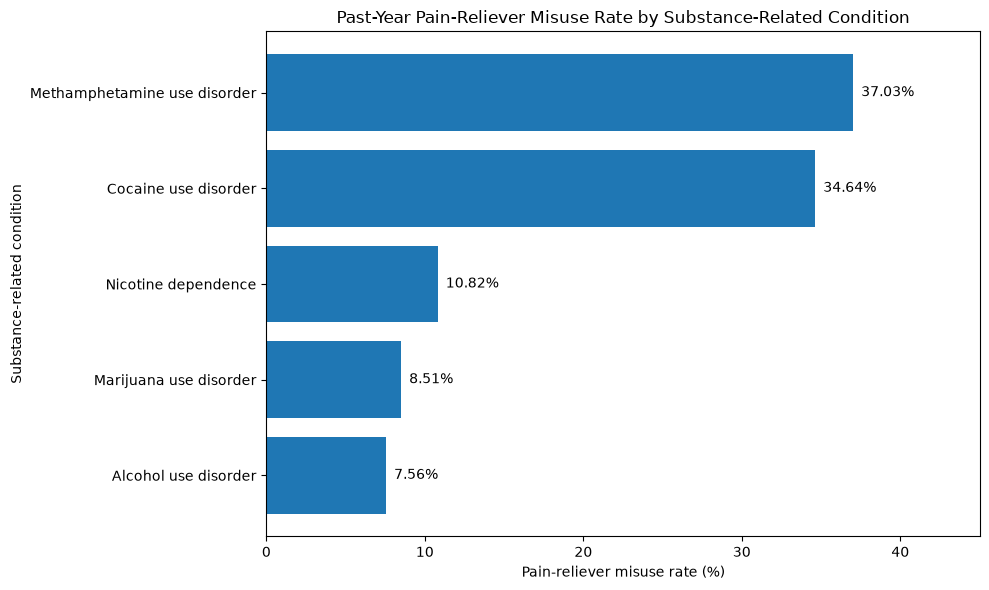

In [133]:
import os
import matplotlib.pyplot as plt

# Make a copy so we can round for display
plot_df = substance_rates_df.copy()
plot_df["Pain-reliever misuse rate"] = plot_df["Pain-reliever misuse rate"].round(2)

# Optional: make an output folder for saved visuals
os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["Substance-related condition"],
    plot_df["Pain-reliever misuse rate"]
)

plt.xlabel("Pain-reliever misuse rate (%)")
plt.ylabel("Substance-related condition")
plt.title("Past-Year Pain-Reliever Misuse Rate by Substance-Related Condition")

# Add value labels at the end of each bar
for i, value in enumerate(plot_df["Pain-reliever misuse rate"]):
    plt.text(value + 0.5, i, f"{value:.2f}%", va="center")

plt.xlim(0, plot_df["Pain-reliever misuse rate"].max() + 8)
plt.tight_layout()

# Save for GitHub / portfolio
plt.savefig("outputs/pain_relief_misuse_by_substance_condition.png", dpi=300, bbox_inches="tight")

plt.show()

In [134]:
risk_count_rates = (
    clean_df.groupby("Substance_Risk_Count")["PNRNMYR"]
    .mean()
    .mul(100)
    .reset_index()
)

risk_count_rates.columns = [
    "Substance Risk Count",
    "Pain-reliever misuse rate"
]

risk_count_rates["Pain-reliever misuse rate"] = (
    risk_count_rates["Pain-reliever misuse rate"].round(2)
)

risk_count_rates

,Substance Risk Count,Pain-reliever misuse rate
0,0,1.75
1,1,5.50
2,2,10.92
3,3,25.57


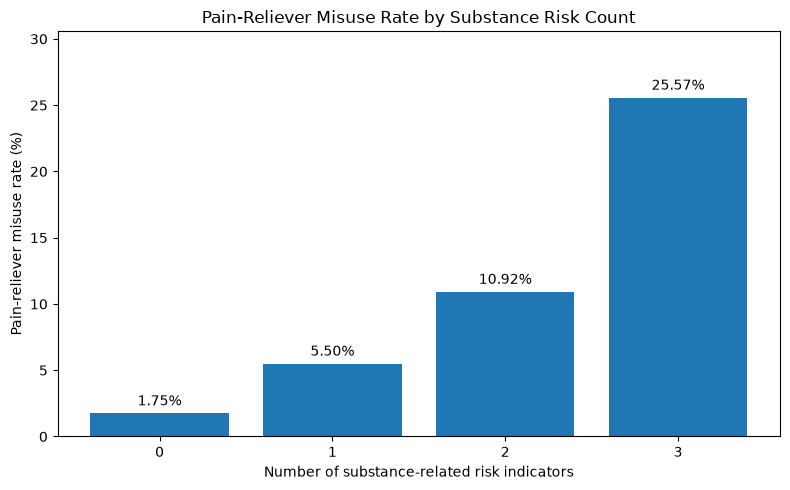

In [135]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_count_rates["Substance Risk Count"].astype(str),
    risk_count_rates["Pain-reliever misuse rate"]
)

plt.xlabel("Number of substance-related risk indicators")
plt.ylabel("Pain-reliever misuse rate (%)")
plt.title("Pain-Reliever Misuse Rate by Substance Risk Count")

for i, value in enumerate(risk_count_rates["Pain-reliever misuse rate"]):
    plt.text(
        i,
        value + 0.6,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(
    0,
    risk_count_rates["Pain-reliever misuse rate"].max() + 5
)

plt.tight_layout()

plt.savefig(
    "outputs/pain_relief_misuse_by_substance_risk_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [136]:
model_comparison_df = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Expanded Logistic Regression": [
        0.184,
        0.273,
        0.220,
        0.737,
        0.147
    ],
    "Expanded Random Forest": [
        0.144,
        0.263,
        0.186,
        0.731,
        0.117
    ]
})

model_comparison_df

,Metric,Expanded Logistic Regression,Expanded Random Forest
0,Precision,0.184,0.144
1,Recall,0.273,0.263
2,F1,0.220,0.186
3,ROC-AUC,0.737,0.731
4,PR-AUC,0.147,0.117


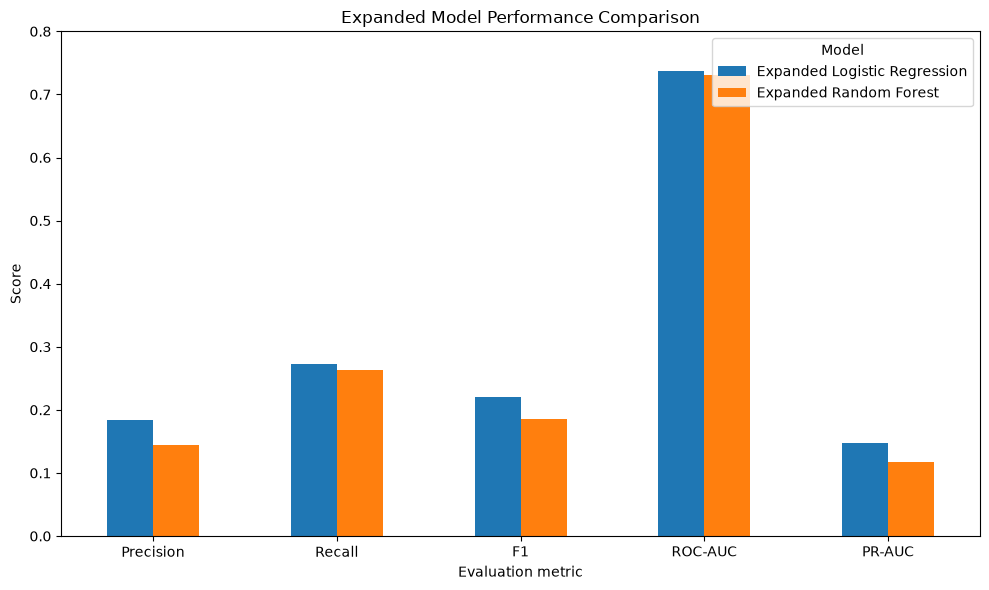

In [137]:
plot_df = model_comparison_df.set_index("Metric")

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Score")
plt.xlabel("Evaluation metric")
plt.title("Expanded Model Performance Comparison")
plt.xticks(rotation=0)
plt.ylim(0, 0.80)

plt.legend(
    title="Model",
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "outputs/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [138]:
# Create readable labels for the strongest model coefficients

feature_label_map = {
    "cat__IRPYUD5MTH_1": "Methamphetamine use disorder",
    "cat__IRPYUD5COC_1": "Cocaine use disorder",
    "cat__IRPYUD5MTH_0": "No methamphetamine use disorder",
    "cat__IRPYUD5COC_0": "No cocaine use disorder",
    "cat__IRPYUD5MRJ_1": "Marijuana use disorder",
    "cat__IRPMNICDEP_1": "Nicotine dependence",
    "cat__IRPYUD5ALC_1": "Alcohol use disorder",
    "cat__KSSLR6MONED_Missing_1": "K6 score missing",
    "cat__IRWRKSTAT18_3": "Unemployed",
    "cat__CATAG6_2": "Age category 2",
    "cat__HEALTH2_4": "Fair/Poor overall health",
    "num__KSSLR6MONED": "K6 psychological distress score",
    "num__WHODASDASC": "WHODAS functional impairment"
}

top_coef_plot = coef_df_exp.head(12).copy()

top_coef_plot["Label"] = (
    top_coef_plot["Feature"]
    .map(feature_label_map)
    .fillna(top_coef_plot["Feature"])
)

top_coef_plot = top_coef_plot.sort_values("Coefficient")

top_coef_plot[["Label", "Coefficient"]]

,Label,Coefficient
29,No methamphetamine use disorder,-0.776658
31,No cocaine use disorder,-0.603203
2,Age category 2,-0.335571
4,cat__CATAG6_4,0.289857
22,cat__HEALTH2_4.0,0.315352
13,Unemployed,0.374980
34,K6 score missing,0.419826
26,Alcohol use disorder,0.488945
24,Nicotine dependence,0.493248
28,Marijuana use disorder,0.500333


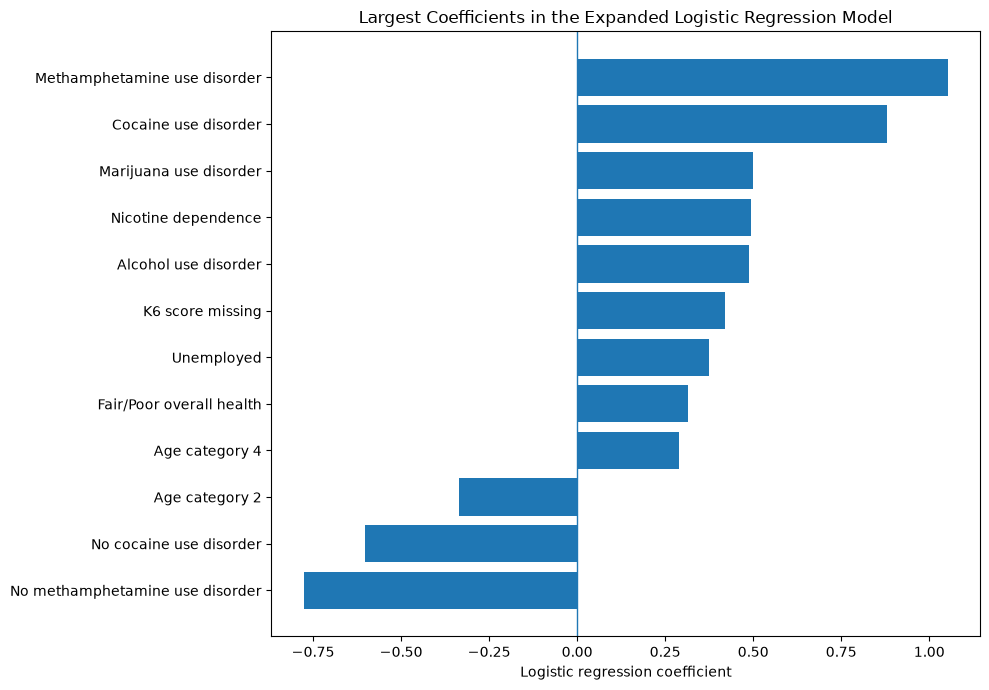

In [140]:
feature_label_map.update({
    "cat__HEALTH2_4.0": "Fair/Poor overall health",
    "cat__CATAG6_4": "Age category 4"
})

top_coef_plot["Label"] = (
    top_coef_plot["Feature"]
    .map(feature_label_map)
    .fillna(top_coef_plot["Feature"])
)

top_coef_plot = top_coef_plot.sort_values("Coefficient")

plt.figure(figsize=(10, 7))

plt.barh(
    top_coef_plot["Label"],
    top_coef_plot["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic regression coefficient")
plt.ylabel("")
plt.title("Largest Coefficients in the Expanded Logistic Regression Model")

plt.tight_layout()

plt.savefig(
    "outputs/logistic_regression_top_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

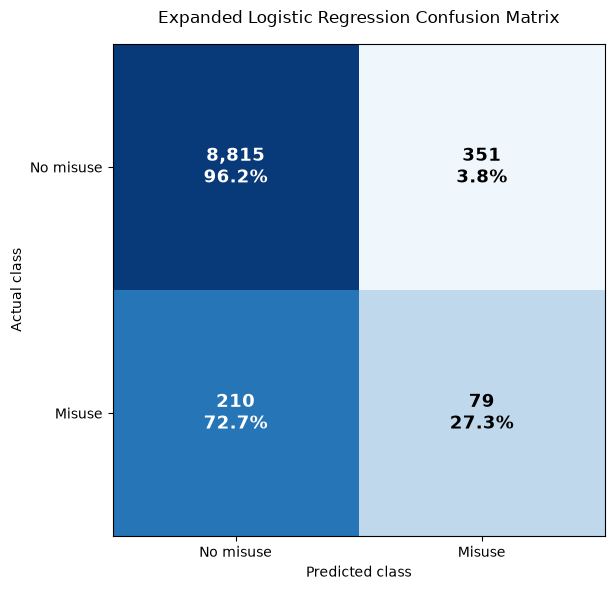

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_exp,
    test_preds_exp
)

# Convert each row to percentages
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 6))

# Use percentages for the shading so both classes remain visible
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)

labels = ["No misuse", "Misuse"]

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

ax.set_title(
    "Expanded Logistic Regression Confusion Matrix",
    pad=15
)

# Add count + percentage to each cell
for i in range(2):
    for j in range(2):

        pct = cm_pct[i, j]
        count = cm[i, j]

        # White text on dark cells, dark text on light cells
        text_color = "white" if pct > 50 else "black"

        ax.text(
            j,
            i,
            f"{count:,}\n{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color
        )

plt.tight_layout()

plt.savefig(
    "outputs/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Limitations

- The analysis is cross-sectional, so associations should not be interpreted as causal or as evidence of future risk.
- The outcome is rare (about 3% of the unweighted adult analytical sample), which limits precision and makes accuracy alone misleading.
- Survey weights are retained for descriptive population-weighted percentages, but the machine-learning models are unweighted and should not be described as nationally representative prediction models.
- Feature selection was targeted rather than exhaustive across all 2,600+ NSDUH variables. Additional codebook-guided feature exploration may improve discrimination in a future version.
- Some predictors measure related behavioral-health constructs, so coefficient magnitude should not be interpreted as an isolated causal effect.
- The test partition was examined during iterative model development. Reported test metrics are therefore best treated as development evidence rather than a pristine, untouched final performance estimate.
- The model is an analytical demonstration and is not a clinical screening, diagnostic, or treatment tool.


## Conclusion

The analysis found that substance-use indicators—particularly methamphetamine and cocaine use disorder—provided the strongest additional signal for distinguishing adults who reported past-year prescription pain-reliever misuse. Psychological distress, functional impairment, health status, employment, age, education, and income also contributed information, although individual effects were generally modest.

Among the expanded models tested, logistic regression provided the strongest overall balance of precision, F1, ROC-AUC, and PR-AUC in the current development workflow, while the random forest offered a nonlinear comparison. The project illustrates an end-to-end analytics process: interpreting a large federal codebook, selecting and cleaning variables, evaluating associations, engineering features, handling severe class imbalance, tuning models with validation data, and communicating model limitations transparently.

Future work can expand the codebook search, evaluate additional predictors, and use a fresh holdout or cross-validation design for a more rigorous final performance estimate.
